<a href="https://colab.research.google.com/github/javeriasalman789-jpg/Anxiety-Prediction-ML/blob/main/Anxiety-Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/anxiety_prediction_data.csv')
df.head()

df.info()

df.isnull().sum()

df.describe()

X = df.drop('Anxiety Level (1-10)', axis=1)
y = df['Anxiety Level (1-10)']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

In [2]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])  # added missing parenthesis

#check the encoded data
X.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10)
0,29,0,0,6.0,2.7,181,10,1,0,10,114,14,4,0,1,3,1,7
1,46,2,8,6.2,5.7,200,8,1,1,1,62,23,2,1,0,2,0,8
2,64,1,9,5.0,3.7,117,4,0,1,1,91,28,3,0,0,1,1,1
3,20,0,10,5.8,2.8,360,6,1,0,4,86,17,3,0,0,0,0,1
4,49,0,9,8.2,2.3,247,4,1,0,1,98,19,4,1,1,1,0,3


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8800, 18)
X_test shape: (2200, 18)
y_train shape: (8800,)
y_test shape: (2200,)


In [4]:

# Linear Regression (Baseline Model)
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)


#  Predictions
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# First 10 Test Predictions
first_10_predictions = pd.DataFrame({
    'Actual Value': y_test.iloc[:10].values if hasattr(y_test, 'iloc') else y_test[:10],
    'Predicted Value': y_test_pred[:10]
})

print("First 10 Test Set Predictions (Linear Regression)")
display(first_10_predictions)




First 10 Test Set Predictions (Linear Regression)


,Actual Value,Predicted Value
0,5.0,5.274387
1,5.0,4.819819
2,10.0,6.992137
3,1.0,1.435050
4,1.0,2.880782
5,3.0,1.082162
6,4.0,5.702547
7,5.0,3.473598
8,4.0,3.822056
9,4.0,4.639583


In [5]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Linear Regression Test Set Evaluation
# Calculate metrics for Test Set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Create DataFrame for Test Set metrics
test_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("Linear Regression Test Set Evaluation Measures")
display(test_metrics)


Linear Regression Test Set Evaluation Measures


,Metric,Test Set
0,MAE,0.893138
1,MSE,1.264665
2,RMSE,1.124573
3,R² Score,0.727071


In [6]:

#  Evaluation Metrics Function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Calculate Metrics
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

#  Evaluation Metrics Table
lr_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Train Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("\n Linear Regression Evaluation Metrics")
display(lr_metrics)


 Linear Regression Evaluation Metrics


,Metric,Train Set,Test Set
0,MAE,0.901601,0.893138
1,MSE,1.272088,1.264665
2,RMSE,1.127869,1.124573
3,R² Score,0.715569,0.727071


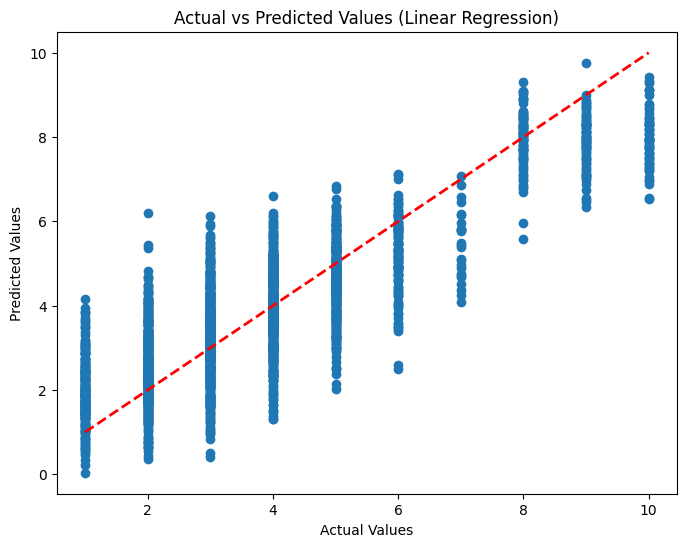

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Linear Regression)")
plt.show()

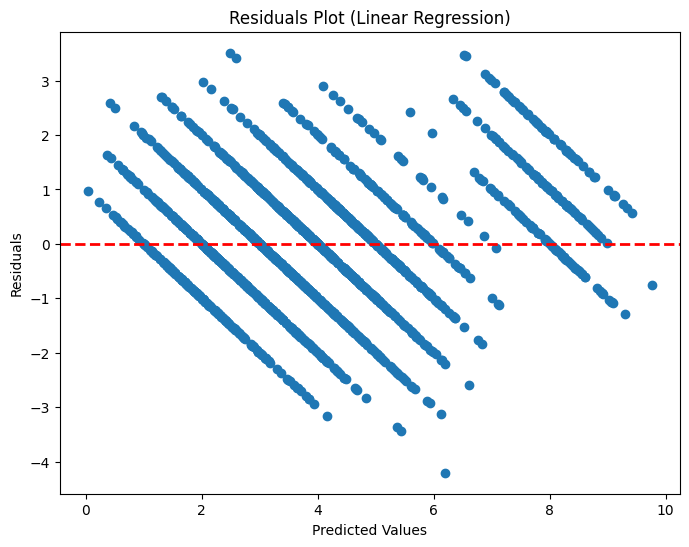

In [8]:

# Residuals Plot
residuals = y_test - y_test_pred
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Linear Regression)")
plt.show()

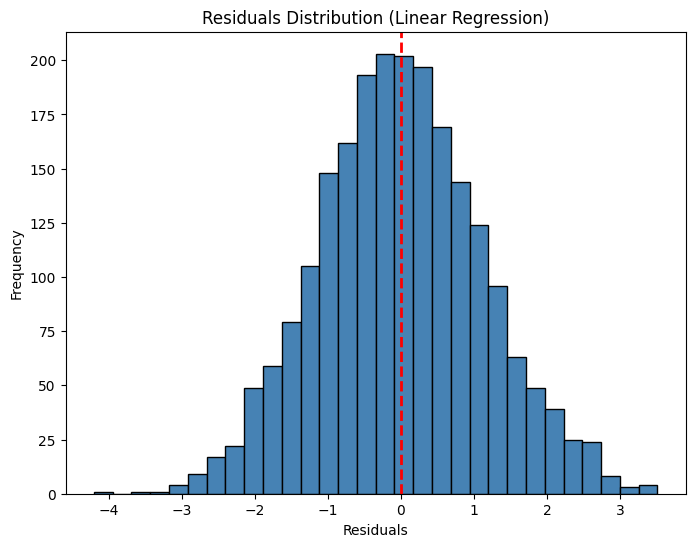

In [9]:

# Residuals Distribution
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)  # mean zero line
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Linear Regression)")
plt.show()

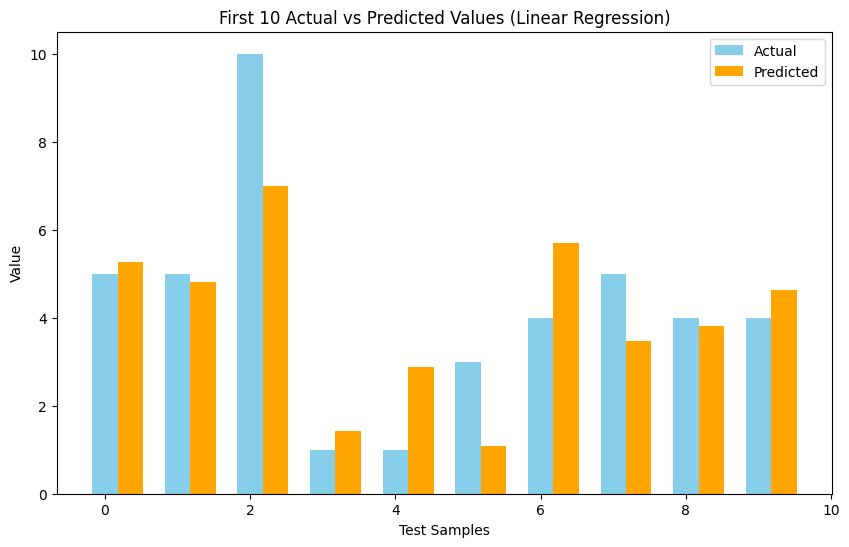

In [10]:

# First 10 Predictions Bar Graph
first_10_actual = y_test[:10]
first_10_pred = y_test_pred[:10]
x = np.arange(len(first_10_actual))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x, first_10_actual, width, label='Actual', color='skyblue')
plt.bar(x + width, first_10_pred, width, label='Predicted', color='orange')
plt.xlabel("Test Samples")
plt.ylabel("Value")
plt.title("First 10 Actual vs Predicted Values (Linear Regression)")
plt.legend()
plt.show()

In [11]:

# Multiple Linear Regression
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train Multiple Linear Regression Model
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predictions
y_train_pred = mlr.predict(X_train)
y_test_pred = mlr.predict(X_test)

#  First 10 Test Predictions
first_10_predictions = pd.DataFrame({
    'Actual Value': y_test.iloc[:10].values if hasattr(y_test, 'iloc') else y_test[:10],
    'Predicted Value': y_test_pred[:10]
})

print("First 10 Test Set Predictions (Multiple Linear Regression)")
display(first_10_predictions)

First 10 Test Set Predictions (Multiple Linear Regression)


,Actual Value,Predicted Value
0,5.0,5.274387
1,5.0,4.819819
2,10.0,6.992137
3,1.0,1.435050
4,1.0,2.880782
5,3.0,1.082162
6,4.0,5.702547
7,5.0,3.473598
8,4.0,3.822056
9,4.0,4.639583


In [12]:

#  Evaluation Metrics Function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

#  Calculate Test Set Metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

#  Create Table for Test Set Metrics
test_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score(Accuracy)'],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("Multiple Linear Regression Test Set Evaluation Measures")
display(test_metrics)

Multiple Linear Regression Test Set Evaluation Measures


,Metric,Test Set
0,MAE,0.893138
1,MSE,1.264665
2,RMSE,1.124573
3,R² Score(Accuracy),0.727071


In [13]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate metrics for Train Set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics for Test Set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Create DataFrame for Train vs Test metrics
mlr_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score(Accuracy)'],
    'Train Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("Multiple Linear Regression Evaluation Metrics (Train & Test)")
display(mlr_metrics)


Multiple Linear Regression Evaluation Metrics (Train & Test)


,Metric,Train Set,Test Set
0,MAE,0.901601,0.893138
1,MSE,1.272088,1.264665
2,RMSE,1.127869,1.124573
3,R² Score(Accuracy),0.715569,0.727071


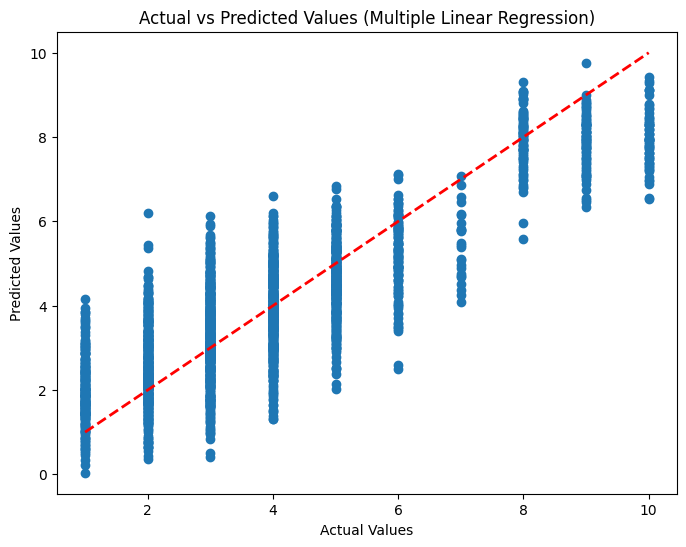

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Multiple Linear Regression)")
plt.show()


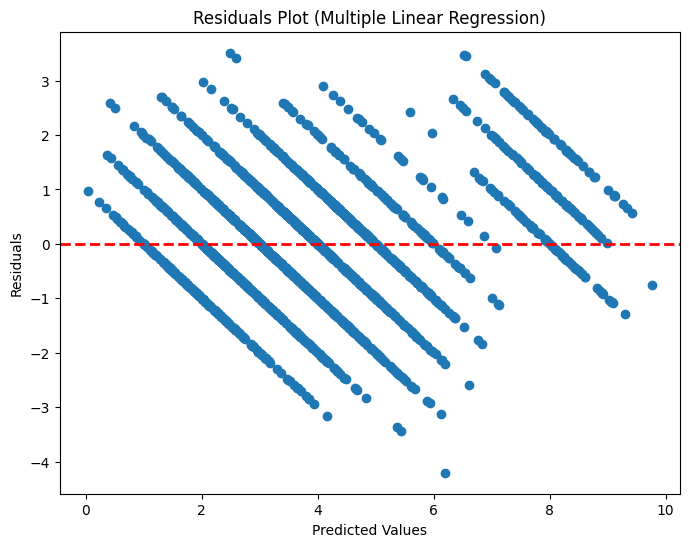

In [15]:

# Residuals Plot
residuals = y_test - y_test_pred
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Multiple Linear Regression)")
plt.show()


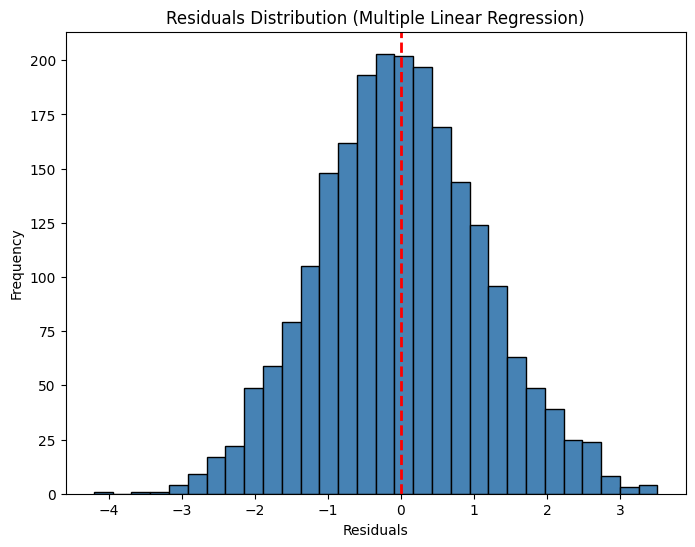

In [16]:

# Residuals Distribution
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)  # mean zero line
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Multiple Linear Regression)")
plt.show()

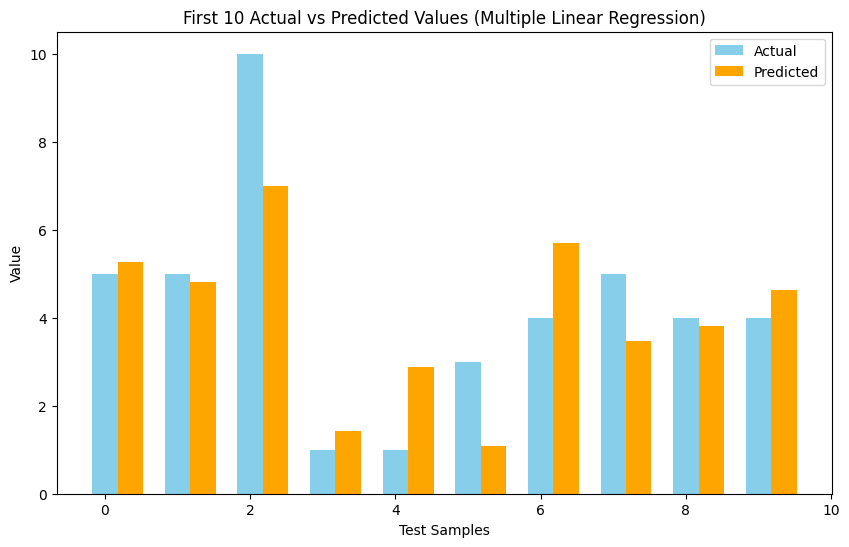

In [17]:

# First 10 Predictions Bar Graph
first_10_actual = y_test[:10]
first_10_pred = y_test_pred[:10]
x = np.arange(len(first_10_actual))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x, first_10_actual, width, label='Actual', color='skyblue')
plt.bar(x + width, first_10_pred, width, label='Predicted', color='orange')
plt.xlabel("Test Samples")
plt.ylabel("Value")
plt.title("First 10 Actual vs Predicted Values (Multiple Linear Regression)")
plt.legend()
plt.show()

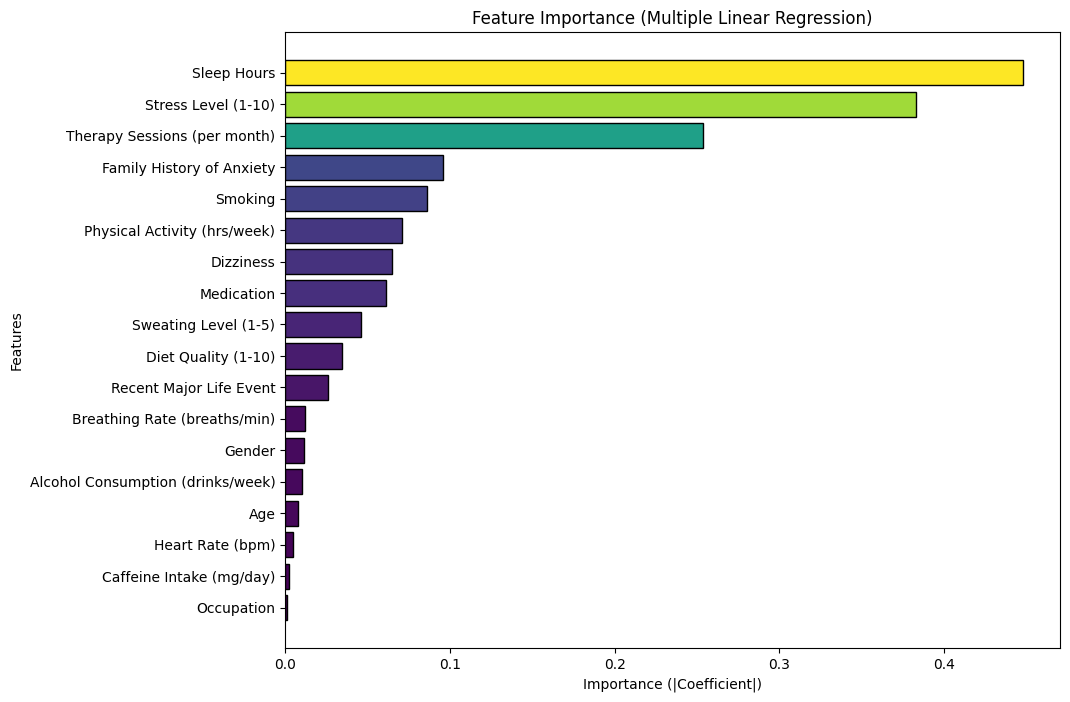

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get feature importance (absolute coefficients)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(mlr.coef_)
})

# Sort by importance descending
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)  # ascending for horizontal bar

# Color gradient based on importance
colors = plt.cm.viridis(feature_importance['Importance'] / feature_importance['Importance'].max())

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors, edgecolor='black')
plt.xlabel("Importance (|Coefficient|)")
plt.ylabel("Features")
plt.title("Feature Importance (Multiple Linear Regression)")
plt.show()


// Polynomial regression


In [19]:

# Polynomial Regression
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#  Set polynomial degree
degree = 2

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train Linear Regression on Polynomial Feature
pr = LinearRegression()
pr.fit(X_train_poly, y_train)

# Predictions
y_train_pred = pr.predict(X_train_poly)
y_test_pred = pr.predict(X_test_poly)

# First 10 Test Predictions
first_10_predictions = pd.DataFrame({
    'Actual Value': y_test.iloc[:10].values if hasattr(y_test, 'iloc') else y_test[:10],
    'Predicted Value': y_test_pred[:10]
})

print(" First 10 Test Set Predictions (Polynomial Regression)")
display(first_10_predictions)


 First 10 Test Set Predictions (Polynomial Regression)


,Actual Value,Predicted Value
0,5.0,5.337938
1,5.0,4.719374
2,10.0,7.128524
3,1.0,1.583073
4,1.0,2.530714
5,3.0,1.443716
6,4.0,5.284470
7,5.0,3.353107
8,4.0,3.459088
9,4.0,4.047633


In [20]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate Test Set Metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Create DataFrame for Test Set Metrics
test_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("Polynomial Regression Test Set Evaluation Measures")
display(test_metrics)


Polynomial Regression Test Set Evaluation Measures


,Metric,Test Set
0,MAE,0.851540
1,MSE,1.130895
2,RMSE,1.063436
3,R² Score,0.755940


In [21]:

#  Evaluation Metrics Function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

#  Train vs Test Metrics
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

pr_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Train Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("🔹 Polynomial Regression Evaluation Metrics (Train & Test)")
display(pr_metrics)

🔹 Polynomial Regression Evaluation Metrics (Train & Test)


,Metric,Train Set,Test Set
0,MAE,0.836879,0.851540
1,MSE,1.086807,1.130895
2,RMSE,1.042500,1.063436
3,R² Score,0.756997,0.755940


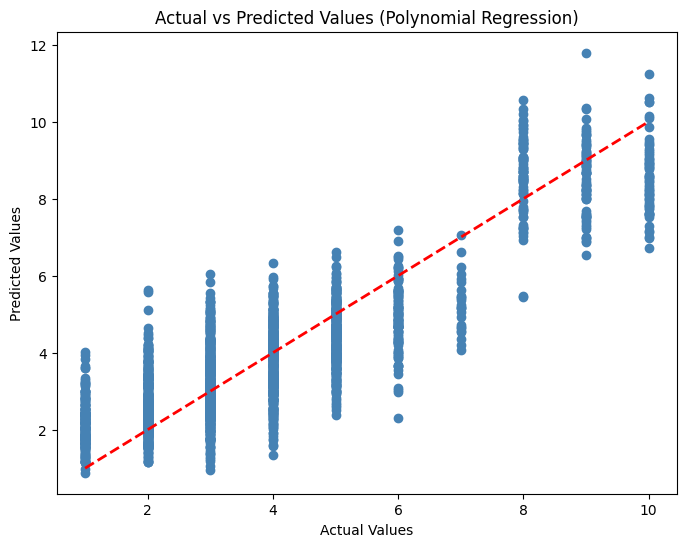

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Residuals
residuals = y_test - y_test_pred

# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)  # perfect prediction li
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Polynomial Regression)")
plt.show()

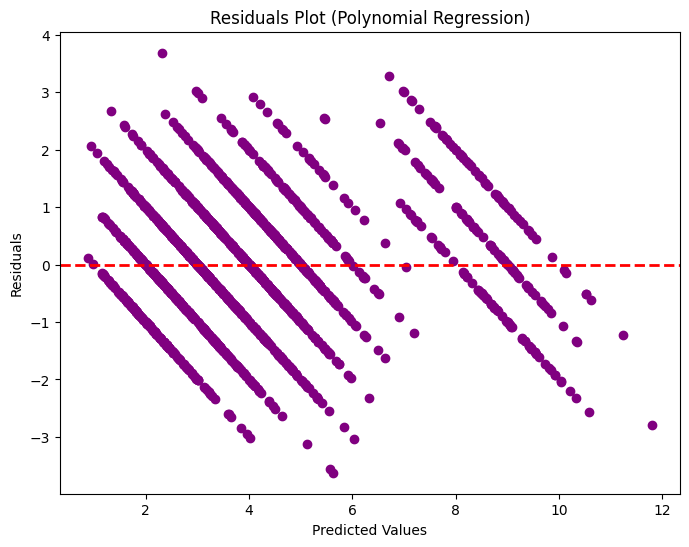

In [23]:

# Residuals Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)  # zero error line
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Polynomial Regression)")
plt.show()

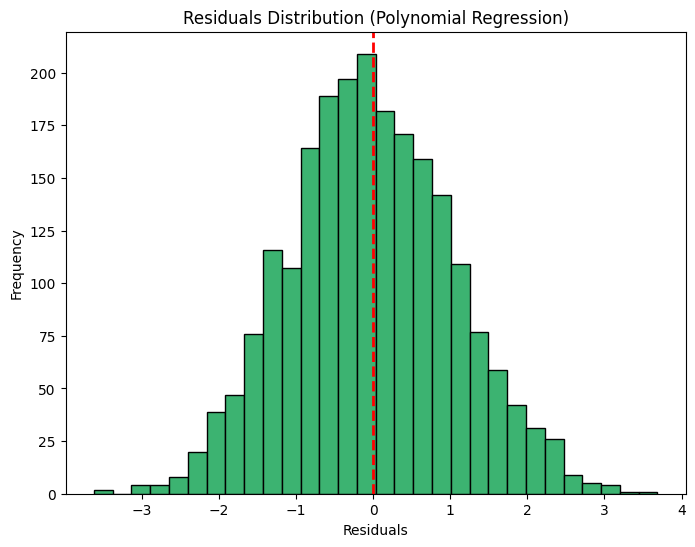

In [24]:

# Residuals Distribution
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='mediumseagreen', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Polynomial Regression)")
plt.show()


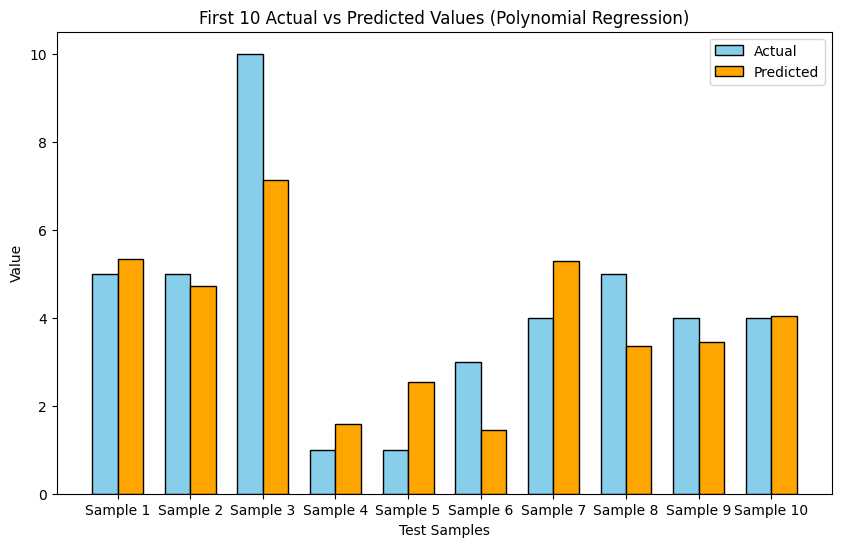

In [25]:

#First 10 Predictions Bar Chart
first_10_actual = y_test[:10]
first_10_pred = y_test_pred[:10]
x = np.arange(len(first_10_actual))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x, first_10_actual, width, label='Actual', color='skyblue', edgecolor='black')
plt.bar(x + width, first_10_pred, width, label='Predicted', color='orange', edgecolor='black')
plt.xlabel("Test Samples")
plt.ylabel("Value")
plt.title("First 10 Actual vs Predicted Values (Polynomial Regression)")
plt.xticks(x + width/2, [f"Sample {i+1}" for i in x])
plt.legend()
plt.show()


// Decision Tree

In [26]:

# Decision Tree Regression
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Train Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

#  Predictions
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# First 10 Test Predictions
first_10_predictions = pd.DataFrame({
    'Actual Value': y_test.iloc[:10].values if hasattr(y_test, 'iloc') else y_test[:10],
    'Predicted Value': y_test_pred[:10]
})

print("First 10 Test Set Predictions (Decision Tree Regression)")
display(first_10_predictions)


First 10 Test Set Predictions (Decision Tree Regression)


,Actual Value,Predicted Value
0,5.0,7.0
1,5.0,4.0
2,10.0,9.0
3,1.0,2.0
4,1.0,2.0
5,3.0,1.0
6,4.0,5.0
7,5.0,4.0
8,4.0,5.0
9,4.0,6.0


In [27]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate Test Set Metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Create DataFrame for Test Set Metrics
test_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print(" Decision Tree Regression Test Set Evaluation Measures")
display(test_metrics)

 Decision Tree Regression Test Set Evaluation Measures


,Metric,Test Set
0,MAE,1.150455
1,MSE,2.278636
2,RMSE,1.509515
3,R² Score,0.508245


In [28]:

#  Evaluation Metrics Function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

#  Train vs Test Metrics
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

dt_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Train Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print(" Decision Tree Regression Evaluation Metrics (Train & Test)")
display(dt_metrics)


 Decision Tree Regression Evaluation Metrics (Train & Test)


,Metric,Train Set,Test Set
0,MAE,0.0,1.150455
1,MSE,0.0,2.278636
2,RMSE,0.0,1.509515
3,R² Score,1.0,0.508245


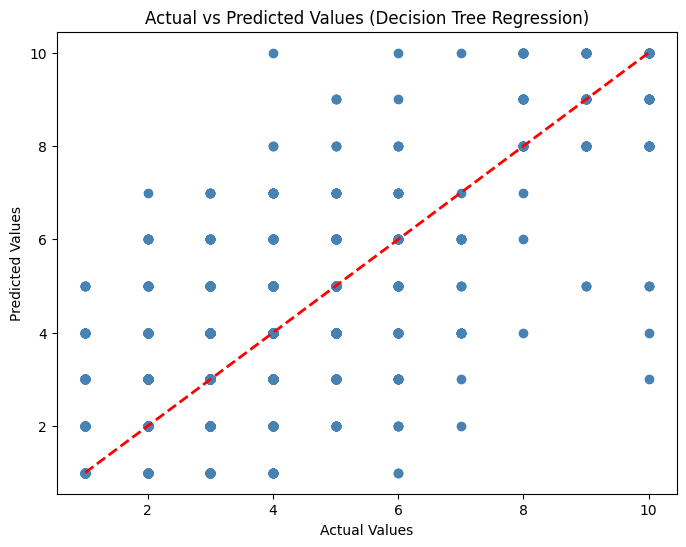

In [29]:
import matplotlib.pyplot as plt
import numpy as np
# Residuals
residuals = y_test - y_test_pred

#  Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Decision Tree Regression)")
plt.show()

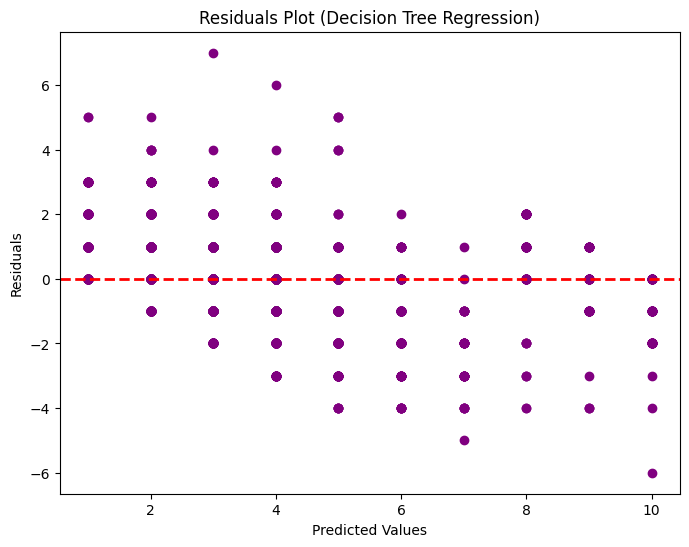

In [30]:

#  Residuals Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Decision Tree Regression)")
plt.show()


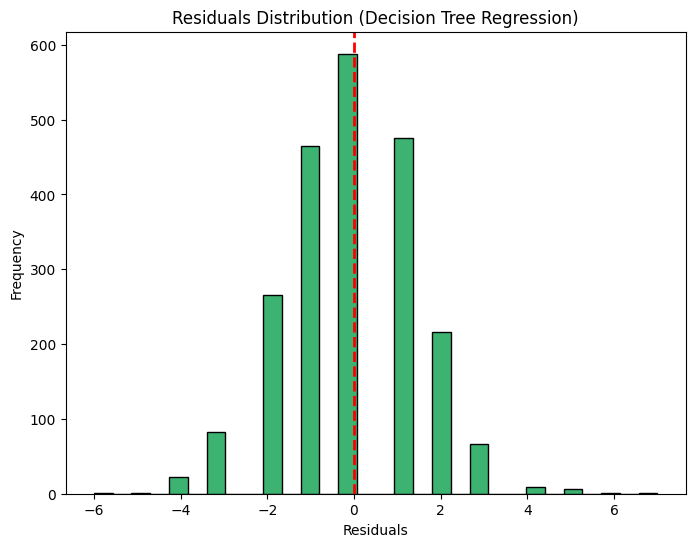

In [31]:

#  Residuals Distribution
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='mediumseagreen', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Decision Tree Regression)")
plt.show()

In [32]:
from sklearn.tree import DecisionTreeRegressor

# Tuned Decision Tree
dt_tuned = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5
)
dt_tuned.fit(X_train, y_train)

# Predictions
y_train_pred = dt_tuned.predict(X_train)
y_test_pred = dt_tuned.predict(X_test)

# Metrics Function
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Train vs Test Metrics
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

dt_tuned_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Train Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("🔹 Tuned Decision Tree Regression Evaluation Metrics (Train & Test)")
display(dt_tuned_metrics)


🔹 Tuned Decision Tree Regression Evaluation Metrics (Train & Test)


,Metric,Train Set,Test Set
0,MAE,0.808503,0.840325
1,MSE,1.020602,1.103509
2,RMSE,1.010248,1.050481
3,R² Score,0.771800,0.761850


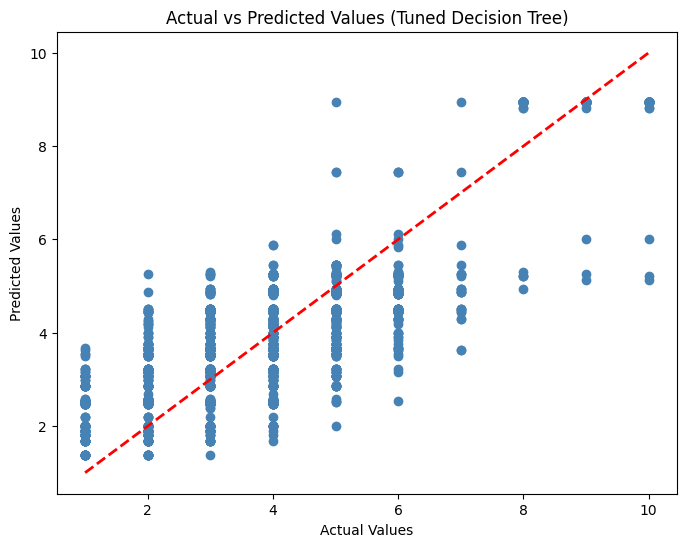

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Residuals
residuals = y_test - y_test_pred

#  Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)  # perfect prediction line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Tuned Decision Tree)")
plt.show()

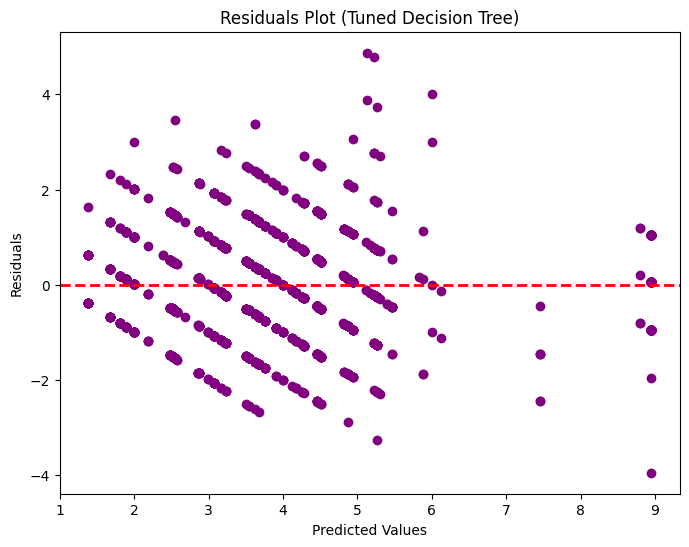

In [34]:

# Residuals Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)  # zero error line
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Tuned Decision Tree)")
plt.show()

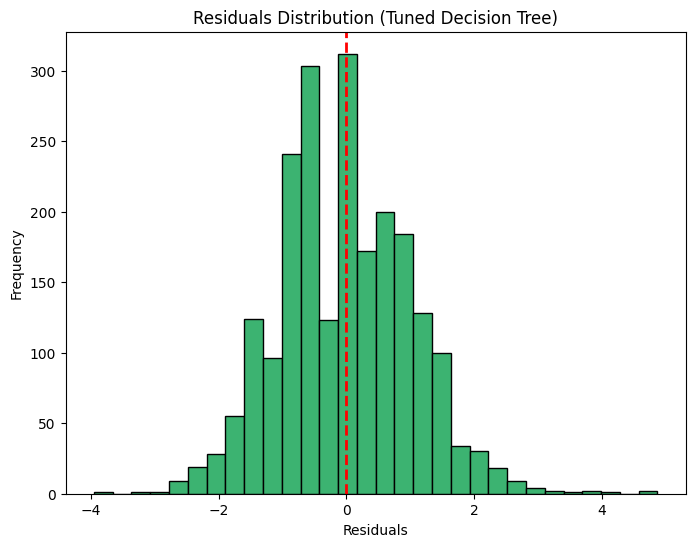

In [35]:

# Residuals Distribution
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='mediumseagreen', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Tuned Decision Tree)")
plt.show()

Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [37]:
y_pred = model.predict(X_test)
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [5.48  4.995 8.88  1.66  2.37  1.635 5.325 3.395 2.93  4.28 ]


In [38]:

# Random Forest Regression
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# First 10 Test Predictions
first_10_predictions = pd.DataFrame({
    'Actual Value': y_test[:10].values,
    'Predicted Value': y_test_pred[:10]
})
print("First 10 Test Predictions")
display(first_10_predictions)


First 10 Test Predictions


,Actual Value,Predicted Value
0,5.0,5.44
1,5.0,4.92
2,10.0,8.85
3,1.0,1.60
4,1.0,2.35
5,3.0,1.64
6,4.0,5.30
7,5.0,3.52
8,4.0,2.93
9,4.0,4.31


In [39]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate evaluation metrics for Test Set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Create a table for Test Set evaluation measures
test_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print(" Test Set Evaluation Measures")
display(test_metrics)

 Test Set Evaluation Measures


,Metric,Test Set
0,MAE,0.819405
1,MSE,1.038418
2,RMSE,1.019028
3,R² Score,0.775898


In [40]:

#  Function to calculate metric
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

#  Calculate Train and Test Metrics
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

#  Metrics Table (Train vs Test)
metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Train Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("\n Random Forest Evaluation Metrics (Train & Test)")
display(metrics_table)


 Random Forest Evaluation Metrics (Train & Test)


,Metric,Train Set,Test Set
0,MAE,0.309874,0.819405
1,MSE,0.150693,1.038418
2,RMSE,0.388192,1.019028
3,R² Score,0.966306,0.775898


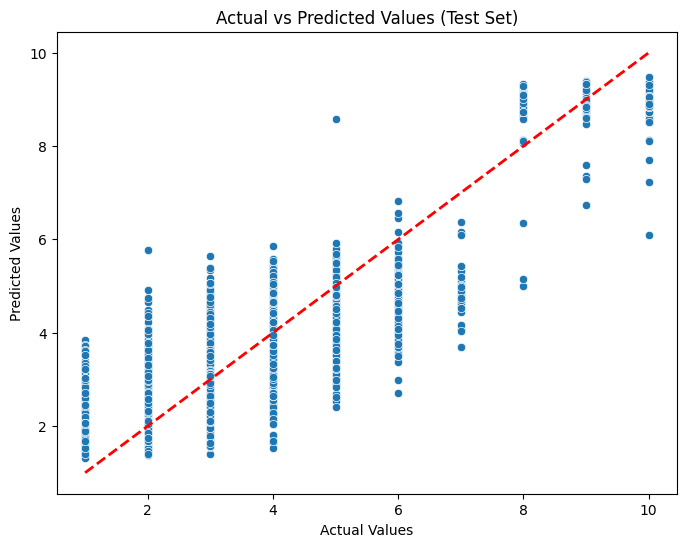

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ Actual vs Predicted Scatter Plot
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Test Set)')
plt.show()

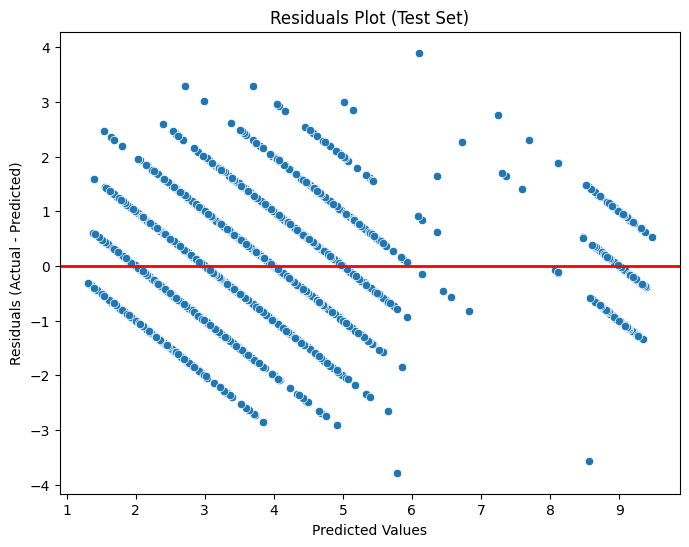

In [42]:
# -------------------------------
# 2️⃣ Residuals Plot
# -------------------------------
residuals = y_test - y_test_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_pred, y=residuals)
plt.axhline(0, color='red', linestyle='-', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals Plot (Test Set)')
plt.show()


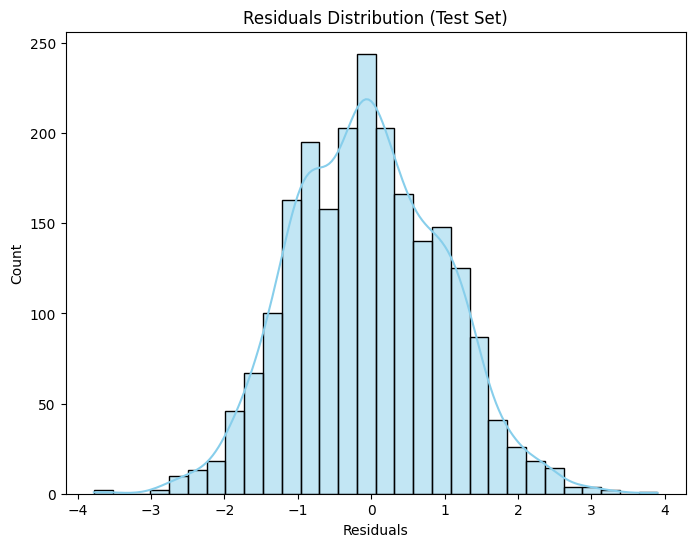

In [43]:
# -------------------------------
# 3️⃣ Distribution of Residuals (optional)
# -------------------------------
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.xlabel('Residuals')
plt.title('Residuals Distribution (Test Set)')
plt.show()

// Tuned Random Forest

In [44]:

# Manually Tuned Random Forest Regressor
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#  Manually tuned parameters
tuned_rf = RandomForestRegressor(
    n_estimators=200,        # more trees → stable predictions
    max_depth=9,            # limit depth → reduce overfitting
    min_samples_split=10,    # prevent very deep splits
    min_samples_leaf=4,      # smoother predictions
    max_features='sqrt',     # randomness → better generalization
    random_state=42,
    n_jobs=-1
)

# Train model
tuned_rf.fit(X_train, y_train)

#  Predictions
y_train_pred = tuned_rf.predict(X_train)
y_test_pred = tuned_rf.predict(X_test)

# Evaluation metrics function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# First 10 Test Set Predictions
first_10_predictions = pd.DataFrame({
    'Actual Value': y_test.iloc[:10].values if hasattr(y_test, 'iloc') else y_test[:10],
    'Predicted Value': y_test_pred[:10]
})

print("First 10 Test Set Predictions (Tuned Random Forest)")
display(first_10_predictions)


First 10 Test Set Predictions (Tuned Random Forest)


,Actual Value,Predicted Value
0,5.0,4.835987
1,5.0,4.407320
2,10.0,8.685993
3,1.0,2.166695
4,1.0,2.674563
5,3.0,2.072935
6,4.0,4.683627
7,5.0,3.066268
8,4.0,3.048610
9,4.0,4.015714


In [45]:
# Tuned Random Forest
# Calculate metrics
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

# Evaluation table
tuned_rf_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Train Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})

print("Manually Tuned Random Forest Evaluation Metrics")
display(tuned_rf_metrics)

Manually Tuned Random Forest Evaluation Metrics


,Metric,Train Set,Test Set
0,MAE,0.751662,0.829875
1,MSE,0.854638,1.035934
2,RMSE,0.924466,1.017808
3,R² Score,0.808908,0.776434


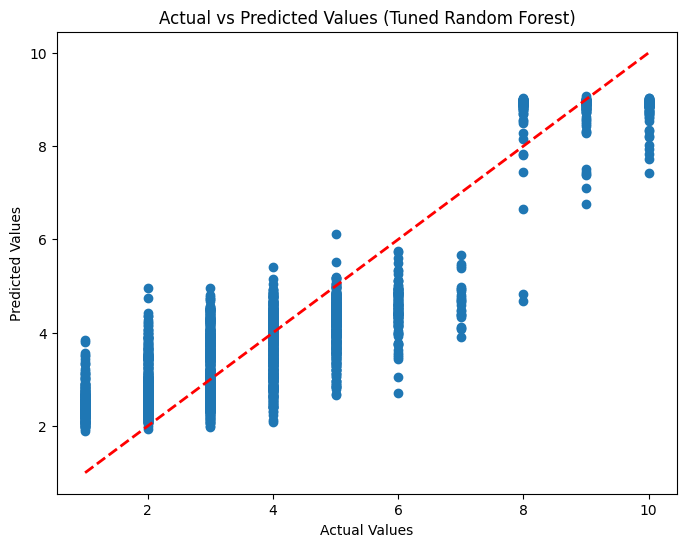

In [46]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred)

# Red perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Tuned Random Forest)")
plt.show()


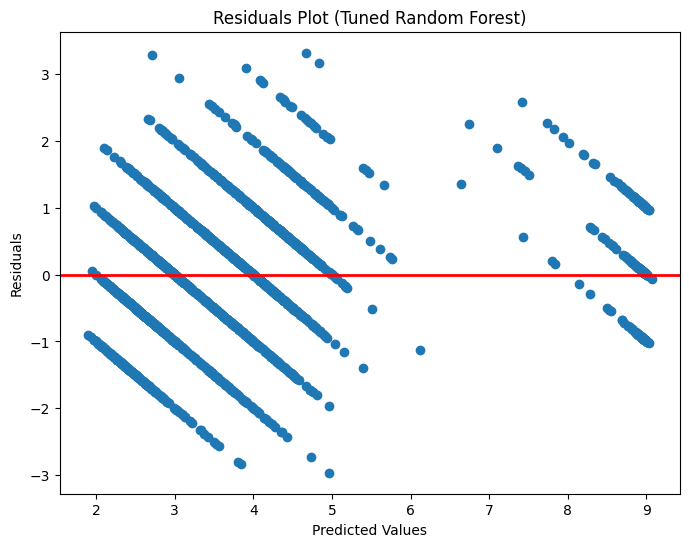

In [47]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals)

# Red reference line at zero residual
plt.axhline(0, color='red', linestyle='-', linewidth=2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Tuned Random Forest)")
plt.show()

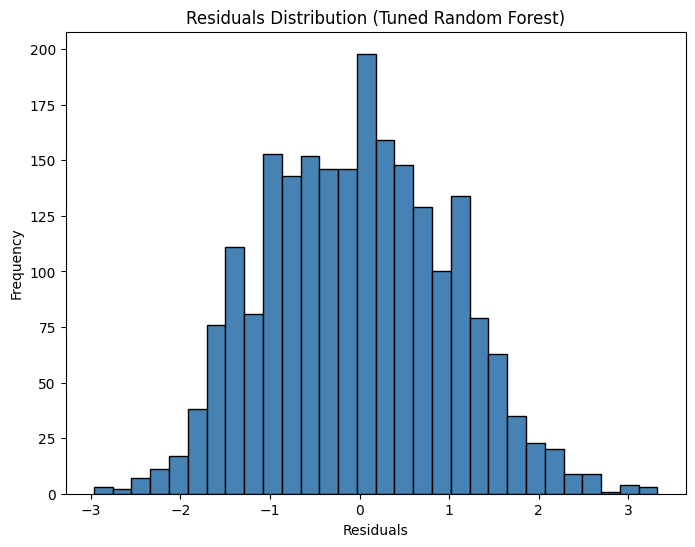

In [48]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Tuned Random Forest)")
plt.show()

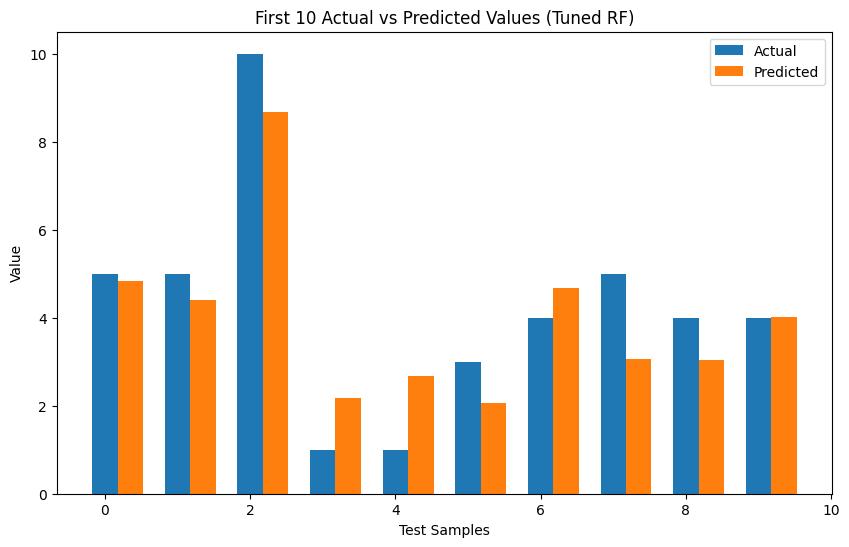

In [49]:
first_10_actual = y_test[:10]
first_10_pred = y_test_pred[:10]

x = np.arange(len(first_10_actual))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x, first_10_actual, width, label='Actual')
plt.bar(x + width, first_10_pred, width, label='Predicted')
plt.xlabel("Test Samples")
plt.ylabel("Value")
plt.title("First 10 Actual vs Predicted Values (Tuned RF)")
plt.legend()
plt.show()

Comparison based table which one is best

In [50]:
import pandas as pd
# Create Wide-Format Comparison Table
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression',
        'Decision Tree (Untuned)',
        'Decision Tree (Tuned)',
        'Random Forest (Untuned)',
        'Random Forest (Tuned)'
    ],
    'Train MAE': [0.9016, 0.9016, 0.8369, 0.0, 0.8085, 0.3099, 0.7517],
    'Train MSE': [1.2721, 1.2721, 1.0868, 0.0, 1.0206, 0.1507, 0.8546],
    'Train RMSE': [1.1279, 1.1279, 1.0425, 0.0, 1.0102, 0.3882, 0.9245],
    'Train R²': [0.7156, 0.7156, 0.7570, 1.0, 0.7718, 0.9663, 0.8089],
    'Test MAE': [0.8931, 0.8931, 0.8515, 1.1505, 0.8403, 0.8194, 0.8299],
    'Test MSE': [1.2647, 1.2647, 1.1309, 2.2786, 1.1035, 1.0384, 1.0359],
    'Test RMSE': [1.1246, 1.1246, 1.0634, 1.5095, 1.0505, 1.0190, 1.0178],
    'Test R²': [0.7271, 0.7271, 0.7559, 0.5082, 0.7619, 0.7759, 0.7764]
})

# Display the table
print("Regression Models Comparison (Wide Format)")
display(comparison_df)


Regression Models Comparison (Wide Format)


,Model,Train MAE,Train MSE,Train RMSE,Train R²,Test MAE,Test MSE,Test RMSE,Test R²
0,Linear Regression,0.9016,1.2721,1.1279,0.7156,0.8931,1.2647,1.1246,0.7271
1,Multiple Linear Regression,0.9016,1.2721,1.1279,0.7156,0.8931,1.2647,1.1246,0.7271
2,Polynomial Regression,0.8369,1.0868,1.0425,0.7570,0.8515,1.1309,1.0634,0.7559
3,Decision Tree (Untuned),0.0000,0.0000,0.0000,1.0000,1.1505,2.2786,1.5095,0.5082
4,Decision Tree (Tuned),0.8085,1.0206,1.0102,0.7718,0.8403,1.1035,1.0505,0.7619
5,Random Forest (Untuned),0.3099,0.1507,0.3882,0.9663,0.8194,1.0384,1.0190,0.7759
6,Random Forest (Tuned),0.7517,0.8546,0.9245,0.8089,0.8299,1.0359,1.0178,0.7764


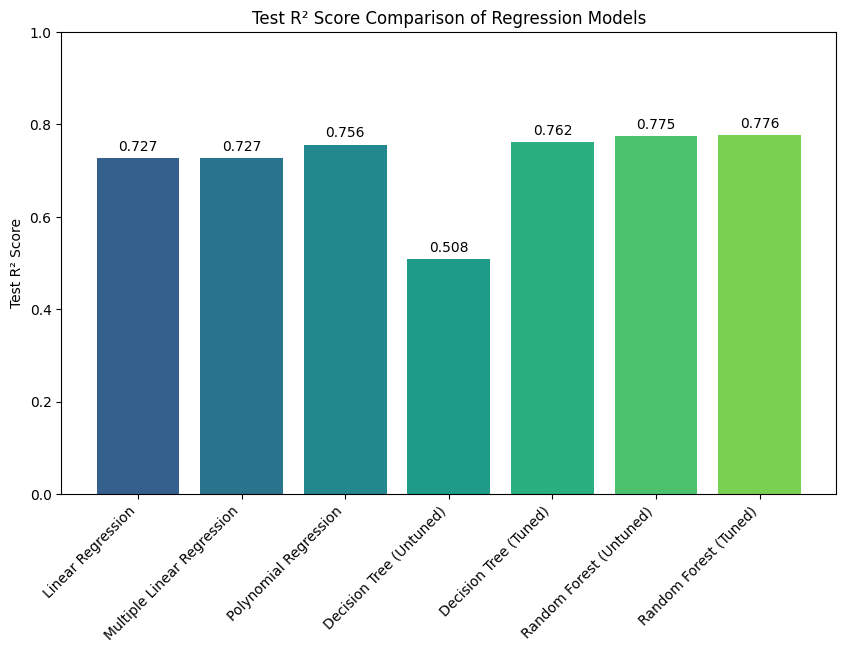

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = [
    'Linear Regression',
    'Multiple Linear Regression',
    'Polynomial Regression',
    'Decision Tree (Untuned)',
    'Decision Tree (Tuned)',
    'Random Forest (Untuned)',
    'Random Forest (Tuned)'
]

# Test Set Metrics
test_r2 = [0.7271, 0.7271, 0.7559, 0.5082, 0.7619, 0.775, 0.7764]
test_rmse = [1.1246, 1.1246, 1.0634, 1.5095, 1.0505, 1.0190, 1.0178]

# Test R² Score Comparison
plt.figure(figsize=(10,6))
bars = plt.bar(models, test_r2, color=plt.cm.viridis(np.linspace(0.3, 0.8, len(models))))
plt.ylabel("Test R² Score")
plt.ylim(0,1)
plt.title("Test R² Score Comparison of Regression Models")
plt.xticks(rotation=45, ha='right')

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height+0.01, f'{height:.3f}', ha='center', va='bottom')

plt.show()

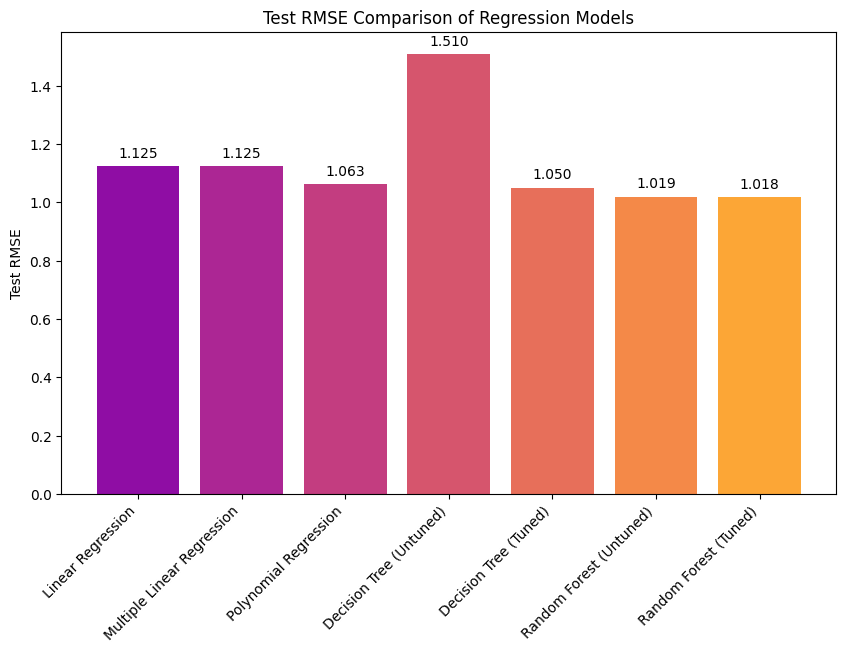

In [52]:

# Test RMSE Comparison
plt.figure(figsize=(10,6))
bars = plt.bar(models, test_rmse, color=plt.cm.plasma(np.linspace(0.3, 0.8, len(models))))
plt.ylabel("Test RMSE")
plt.title("Test RMSE Comparison of Regression Models")
plt.xticks(rotation=45, ha='right')

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height+0.02, f'{height:.3f}', ha='center', va='bottom')

plt.show()

Ensembled Regression

In [53]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Collect predictions from all models
predictions = pd.DataFrame({
    'Linear_Regression': lr.predict(X_test),
    'Multiple_LR': mlr.predict(X_test),
    'Polynomial_Regression': y_test_pred,       # Polynomial regression predictions
    'Decision_Tree': dt.predict(X_test),
    'Tuned_Decision_Tree': dt_tuned.predict(X_test),
    'Random_Forest': rf.predict(X_test),
    'Tuned_Random_Forest': tuned_rf.predict(X_test)
})

#  Assign weights based on model performance
# (Give higher weight to Tuned RF and Polynomial Regression)
weights = {
    'Linear_Regression': 0.1,
    'Multiple_LR': 0.1,
    'Polynomial_Regression': 0.2,
    'Decision_Tree': 0.1,
    'Tuned_Decision_Tree': 0.15,
    'Random_Forest': 0.15,
    'Tuned_Random_Forest': 0.2
}

# Weighted ensemble prediction
ensemble_pred_weighted = sum(predictions[col] * w for col, w in weights.items()) / sum(weights.values())

# Evaluation Metrics Function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Calculate metrics for weighted ensemble
ensemble_mae, ensemble_mse, ensemble_rmse, ensemble_r2 = regression_metrics(y_test, ensemble_pred_weighted)

# Display metrics
weighted_ensemble_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Weighted Ensemble': [ensemble_mae, ensemble_mse, ensemble_rmse, ensemble_r2]
})

print(" Weighted Ensemble Regression Evaluation Metrics")
display(weighted_ensemble_metrics)



 Weighted Ensemble Regression Evaluation Metrics


,Metric,Weighted Ensemble
0,MAE,0.815272
1,MSE,1.010838
2,RMSE,1.005404
3,R² Score,0.781850


In [54]:

# First 10 Weighted Ensemble Predictions
first_10_weighted = pd.DataFrame({
    'Actual': y_test[:10].values if hasattr(y_test, 'iloc') else y_test[:10],
    'Weighted_Ensemble_Predicted': ensemble_pred_weighted[:10]
})

print("First 10 Weighted Ensemble Predictions")
display(first_10_weighted)

First 10 Weighted Ensemble Predictions


,Actual,Weighted_Ensemble_Predicted
0,5.0,5.246757
1,5.0,4.596512
2,10.0,8.443201
3,1.0,1.876329
4,1.0,2.570787
5,3.0,1.690995
6,4.0,5.040581
7,5.0,3.310338
8,4.0,3.305143
9,4.0,4.398995


In [55]:
print(type(dt))


<class 'sklearn.tree._classes.DecisionTreeRegressor'>


    # Apply  Classification Models

In [56]:

#  Define categorize function
def categorize_anxiety(score):
    if score <= 3:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

# Create target column
df['Anxiety_Level_Category'] = df['Anxiety Level (1-10)'].apply(categorize_anxiety)

# Check class imbalance
print("Class distribution:")
print(df['Anxiety_Level_Category'].value_counts())

Class distribution:
Anxiety_Level_Category
Low       5202
Medium    4661
High      1137
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

X = df.drop(['Anxiety_Level_Category', 'Anxiety Level (1-10)'], axis=1)
y = df['Anxiety_Level_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])  # IMPORTAN

In [59]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Balanced training set distribution:")
print(y_train_res.value_counts())

print("\nTest set distribution (original):")
print(y_test.value_counts())

Balanced training set distribution:
Anxiety_Level_Category
Low       4161
Medium    4161
High      4161
Name: count, dtype: int64

Test set distribution (original):
Anxiety_Level_Category
Low       1041
Medium     932
High       227
Name: count, dtype: int64


Logistic Regression


In [60]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score, log_loss,
    confusion_matrix, roc_auc_score
)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize

#  Convert anxiety scores to categories
def categorize_anxiety(level):
    if level <= 3:
        return "Low"
    elif level <= 6:
        return "Medium"
    else:
        return "High"

df['Anxiety_Level_Category'] = df['Anxiety Level (1-10)'].apply(categorize_anxiety)

X = df.drop(['Anxiety_Level_Category', 'Anxiety Level (1-10)'], axis=1)
y = df['Anxiety_Level_Category']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Encode categorical features
cat_cols = X_train.select_dtypes(include='object').columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

#  Apply SMOTE to balance training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Balanced training set distribution:")
print(pd.Series(y_train_res).value_counts())

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression (balanced)
logreg = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',  # handle imbalance
    random_state=42
)
logreg.fit(X_train_scaled, y_train_res)

#  Predictions
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)
y_train_proba = logreg.predict_proba(X_train_scaled)
y_test_proba = logreg.predict_proba(X_test_scaled)

#  First 10 Test Predictions
first_10 = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': y_test_pred[:10]
})
print("First 10 Test Predictions")
display(first_10)



Balanced training set distribution:
Anxiety_Level_Category
Low       4161
Medium    4161
High      4161
Name: count, dtype: int64
First 10 Test Predictions


,Actual,Predicted
0,Low,Low
1,Medium,High
2,Medium,Medium
3,Low,Low
4,Medium,Medium
5,Medium,Medium
6,Medium,Low
7,Medium,Medium
8,High,High
9,Medium,Low


In [61]:

# Get class labels
classes = logreg.classes_

# Predict probabilities
y_test_proba = logreg.predict_proba(X_test_scaled)

#  Binarize y_test for ROC/AUC
y_test_bin = label_binarize(y_test, classes=classes)
macro_auc = roc_auc_score(y_test_bin, y_test_proba, average='macro')

#  Calculate evaluation metric
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
f2 = fbeta_score(y_test, y_test_pred, beta=2, average='weighted', zero_division=0)
loss = log_loss(y_test, y_test_proba)

#  Metrics Table (Test Set)
metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score', 'Log Loss', 'Macro-Average AUC'],
    'Test Set': [accuracy, precision, recall, f1, f2, loss, macro_auc]
})

print("Logistic Regression Evaluation Metrics – Test Set")
display(metrics_table)



Logistic Regression Evaluation Metrics – Test Set


,Metric,Test Set
0,Accuracy,0.792273
1,Precision,0.792492
2,Recall,0.792273
3,F1 Score,0.791908
4,F2 Score,0.792002
5,Log Loss,0.485426
6,Macro-Average AUC,0.915866


In [62]:

#  Classification Metrics Function
classes = logreg.classes_

def classification_metrics(y_true, y_pred, y_proba=None, classes=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
    loss = log_loss(y_true, y_proba) if y_proba is not None else None
    macro_auc = None
    if y_proba is not None and classes is not None:
        y_true_bin = label_binarize(y_true, classes=classes)
        macro_auc = roc_auc_score(y_true_bin, y_proba, average='macro')
    return accuracy, precision, recall, f1, f2, loss, macro_auc

#  Calculate Metrics
train_metrics = classification_metrics(y_train_res, y_train_pred, y_train_proba, classes)
test_metrics = classification_metrics(y_test, y_test_pred, y_test_proba, classes)

# Metrics Table
metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score', 'Log Loss', 'Macro-Average AUC'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})
print("Logistic Regression Evaluation Metrics (Balanced Training Set)")
display(metrics_table)


Logistic Regression Evaluation Metrics (Balanced Training Set)


,Metric,Train Set,Test Set
0,Accuracy,0.815349,0.792273
1,Precision,0.817607,0.792492
2,Recall,0.815349,0.792273
3,F1 Score,0.816350,0.791908
4,F2 Score,0.815719,0.792002
5,Log Loss,0.423898,0.485426
6,Macro-Average AUC,0.936014,0.915866


In [63]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    log_loss, roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import label_binarize

# Confusion Matrix Table
classes = logreg.classes_  # classes in the trained model
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=[f'Actual {c}' for c in classes],
                     columns=[f'Predicted {c}' for c in classes])

print(" Confusion Matrix Table – Logistic Regression (Test Set)")
display(cm_df)




 Confusion Matrix Table – Logistic Regression (Test Set)


,Predicted High,Predicted Low,Predicted Medium
Actual High,207,0,20
Actual Low,3,834,204
Actual Medium,50,180,702


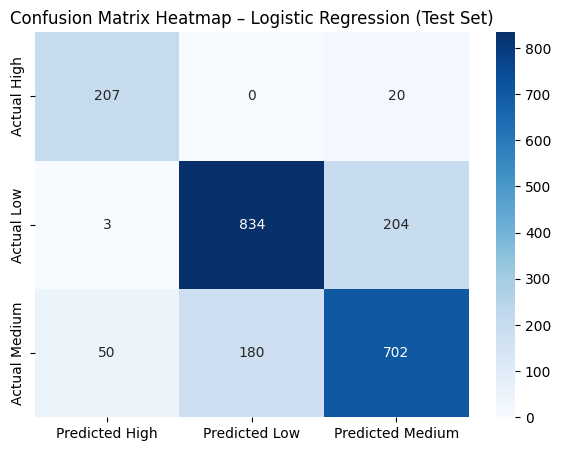

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

#  Confusion Matrix Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Heatmap – Logistic Regression (Test Set)")
plt.show()



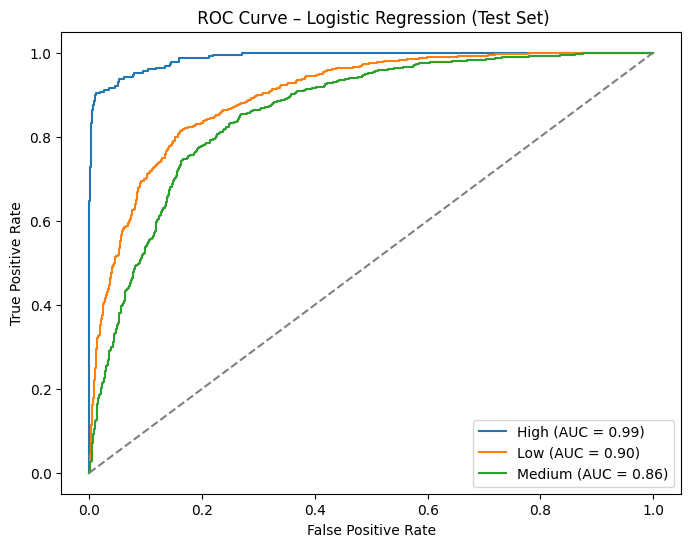

In [65]:

#  Optional: ROC Curves for each class
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve – Logistic Regression (Test Set)')
plt.legend()
plt.show()

APPLY KNN NOW

In [66]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(
    n_neighbors=15,      # smoother boundary → less overfitting
    weights='distance',
    metric='minkowski'
)

knn_clf.fit(X_train_res, y_train_res)


KNeighborsClassifier(n_neighbors=15, weights='distance')

In [67]:

#  Imports
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, log_loss,
    confusion_matrix, roc_curve, roc_auc_score
)

from imblearn.over_sampling import SMOTE

#  Anxiety Score → Category
def categorize_anxiety(score):
    if score <= 3:
        return 'Low'
    elif score <= 7:
        return 'Medium'
    else:
        return 'High'
df['Anxiety_Level_Category'] = df['Anxiety Level (1-10)'].apply(categorize_anxiety)

X = df.drop(['Anxiety Level (1-10)', 'Anxiety_Level_Category'], axis=1)
y = df['Anxiety_Level_Category']

from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include='object').columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#  Feature Scaling (IMPORTANT FOR KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Balanced Training Distribution:")
print(y_train_res.value_counts())


knn_clf = KNeighborsClassifier(
    n_neighbors=15,
    weights='distance',
    metric='minkowski'
)

knn_clf.fit(X_train_res, y_train_res)

y_test_pred = knn_clf.predict(X_test_scaled)
y_test_proba = knn_clf.predict_proba(X_test_scaled)

first_10 = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': y_test_pred[:10]
})

print("First 10 Test Predictions (KNN)")
display(first_10)



Balanced Training Distribution:
Anxiety_Level_Category
High      4162
Low       4162
Medium    4162
Name: count, dtype: int64
First 10 Test Predictions (KNN)


,Actual,Predicted
0,Low,Low
1,Low,Low
2,High,High
3,Medium,High
4,Medium,Low
5,Medium,Medium
6,Low,Low
7,Medium,Low
8,High,High
9,Low,Low


In [68]:

#  Evaluation Metrics (TEST SET)
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score', 'Log Loss'],
    'Test Set': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted'),
        recall_score(y_test, y_test_pred, average='weighted'),
        f1_score(y_test, y_test_pred, average='weighted'),
        fbeta_score(y_test, y_test_pred, beta=2, average='weighted'),
        log_loss(y_test, y_test_proba)
    ]
})

print(" KNN Evaluation Metrics (Test Set)")
display(metrics_df)




 KNN Evaluation Metrics (Test Set)


,Metric,Test Set
0,Accuracy,0.763636
1,Precision,0.763645
2,Recall,0.763636
3,F1 Score,0.762386
4,F2 Score,0.762803
5,Log Loss,0.657508


In [69]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, log_loss
)
import pandas as pd
# Predictions
y_train_pred = knn_clf.predict(X_train_res)
y_train_proba = knn_clf.predict_proba(X_train_res)

y_test_pred = knn_clf.predict(X_test_scaled)
y_test_proba = knn_clf.predict_proba(X_test_scaled)

# Metric function
def classification_metrics(y_true, y_pred, y_proba):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted'),
        fbeta_score(y_true, y_pred, beta=2, average='weighted'),
        log_loss(y_true, y_proba)
    ]

# Calculate metrics
train_metrics = classification_metrics(y_train_res, y_train_pred, y_train_proba)
test_metrics  = classification_metrics(y_test, y_test_pred, y_test_proba)

# Comparison Table
metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score', 'Log Loss'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})

print("KNN Train vs Test Performance Comparison")
display(metrics_table)


KNN Train vs Test Performance Comparison


,Metric,Train Set,Test Set
0,Accuracy,1.000000e+00,0.763636
1,Precision,1.000000e+00,0.763645
2,Recall,1.000000e+00,0.763636
3,F1 Score,1.000000e+00,0.762386
4,F2 Score,1.000000e+00,0.762803
5,Log Loss,2.622551e-08,0.657508


In [70]:

# Confusion Matrix (TABLE FORM)
cm = confusion_matrix(y_test, y_test_pred, labels=knn_clf.classes_)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {c}' for c in knn_clf.classes_],
    columns=[f'Predicted {c}' for c in knn_clf.classes_]
)

print("Confusion Matrix – KNN")
display(cm_df)



Confusion Matrix – KNN


,Predicted High,Predicted Low,Predicted Medium
Actual High,202,0,1
Actual Low,6,769,265
Actual Medium,41,207,709


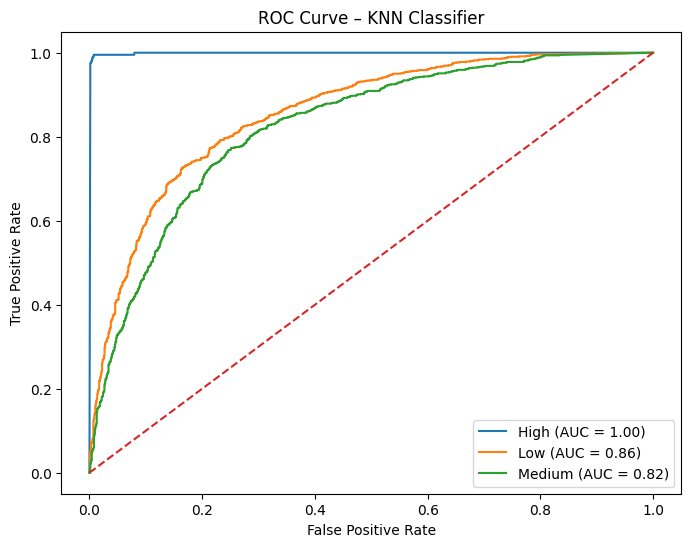

In [71]:

# ROC Curve (Multiclass)
classes = knn_clf.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN Classifier')
plt.legend()
plt.show()

the KNN Model Overfits so we tune it

In [72]:

#  Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    log_loss, confusion_matrix, roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

#  Convert Anxiety Scores to Categories
def categorize_anxiety(level):
    if level <= 3:
        return "Low"
    elif level <= 6:
        return "Medium"
    else:
        return "High"

y_class = df['Anxiety Level (1-10)'].apply(categorize_anxiety)
X = df.drop(['Anxiety Level (1-10)'], axis=1)

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

#  Encode Categorical Features
cat_cols = X_train.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    le_dict[col] = le

#  Apply SMOTE to Balance Training Set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Balanced Training Set Distribution:")
print(pd.Series(y_train_res).value_counts())

#  Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

#  GridSearchCV to Tune KNN
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy')
grid.fit(X_train_scaled, y_train_res)

print(" Best n_neighbors:", grid.best_params_)
print(" Best CV Accuracy:", grid.best_score_)

# Train KNN with Best Parameter
knn = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
knn.fit(X_train_scaled, y_train_res)

#  Predictions
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

y_train_proba = knn.predict_proba(X_train_scaled)
y_test_proba = knn.predict_proba(X_test_scaled)






Balanced Training Set Distribution:
Anxiety Level (1-10)
Low       4161
Medium    4161
High      4161
Name: count, dtype: int64
 Best n_neighbors: {'n_neighbors': 15}
 Best CV Accuracy: 0.9256587712947845


In [73]:

# Evaluation Metrics Function
def classification_metrics(y_true, y_pred, y_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
    loss = log_loss(y_true, y_proba)
    return accuracy, precision, recall, f1, f2, loss

# Train metrics
train_metrics = classification_metrics(y_train_res, y_train_pred, y_train_proba)
# Test metrics
test_metrics = classification_metrics(y_test, y_test_pred, y_test_proba)

#  Train vs Test Metrics Table
metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score', 'Log Loss'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})
print("KNN Evaluation Metrics (After Tuning & SMOTE)")
display(metrics_table)

KNN Evaluation Metrics (After Tuning & SMOTE)


,Metric,Train Set,Test Set
0,Accuracy,0.944885,0.921364
1,Precision,0.945585,0.922000
2,Recall,0.944885,0.921364
3,F1 Score,0.945077,0.921483
4,F2 Score,0.944924,0.921363
5,Log Loss,0.230120,0.442691


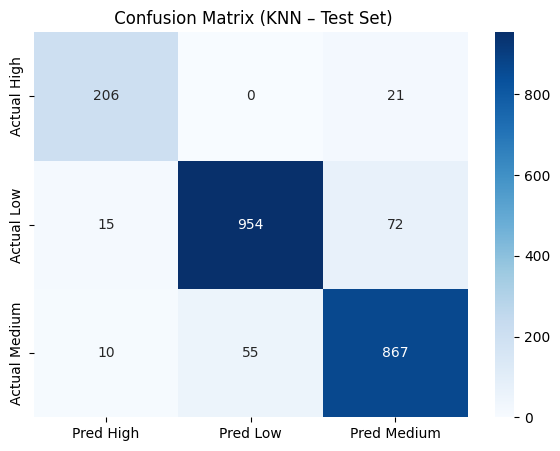

In [74]:

#  Confusion Matrix Heatmap
classes = knn.classes_
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=[f'Actual {c}' for c in classes],
                     columns=[f'Pred {c}' for c in classes])

plt.figure(figsize=(7,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(" Confusion Matrix (KNN – Test Set)")
plt.show()



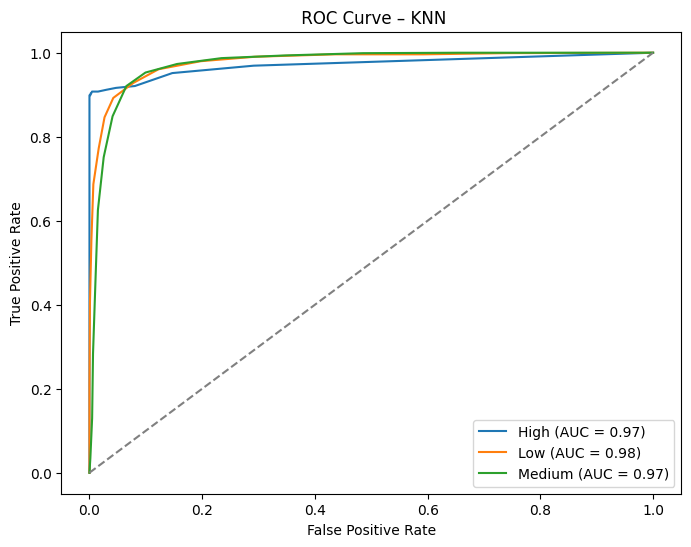

In [75]:

#  ROC Curve
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve – KNN')
plt.legend()
plt.show()

NAIVE BAYES


 Naive Bayes – Train Set Metrics


,Metric,Train Set
0,Accuracy,0.987273
1,Precision,0.987443
2,Recall,0.987273
3,F1 Score,0.987005
4,F2 Score,0.987087
5,Log Loss,0.116487
6,Macro-Average AUC,0.989240


 Naive Bayes – Train vs Test Metrics


,Metric,Train Set,Test Set
0,Accuracy,0.987273,0.990000
1,Precision,0.987443,0.990231
2,Recall,0.987273,0.990000
3,F1 Score,0.987005,0.989804
4,F2 Score,0.987087,0.989851
5,Log Loss,0.116487,0.102911
6,Macro-Average AUC,0.989240,0.990029


Confusion Matrix – Test Set


,Pred High,Pred Low,Pred Medium
Actual High,205,0,22
Actual Low,0,1041,0
Actual Medium,0,0,932


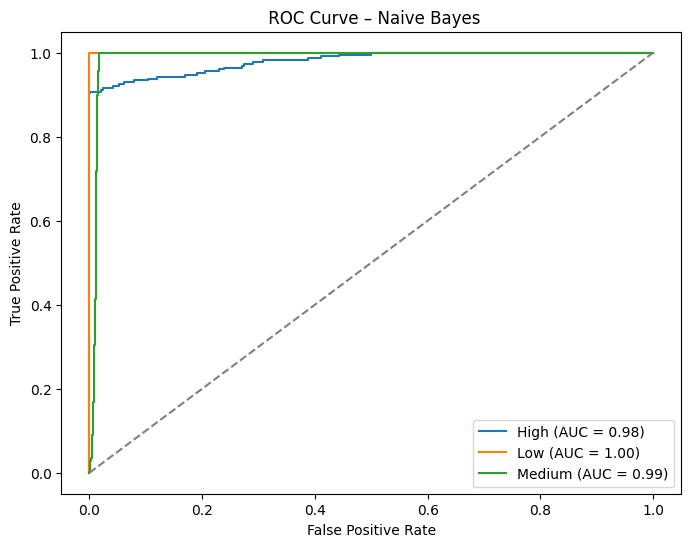

Feature Ablation – Test Accuracy After Removing Each Feature


,Feature Removed,Test Accuracy
18,Anxiety_Level_Category,0.790455
3,Sleep Hours,0.989091
13,Dizziness,0.989545
6,Alcohol Consumption (drinks/week),0.989545
17,Diet Quality (1-10),0.989545
15,Therapy Sessions (per month),0.989545
5,Caffeine Intake (mg/day),0.990000
4,Physical Activity (hrs/week),0.990000
11,Breathing Rate (breaths/min),0.990000
7,Smoking,0.990000


In [76]:

#  Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer, label_binarize
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    log_loss, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns


# Convert Anxiety Scores to Categories
def categorize_anxiety(level):
    if level <= 3:
        return "Low"
    elif level <= 6:
        return "Medium"
    else:
        return "High"

y_class = df['Anxiety Level (1-10)'].apply(categorize_anxiety)
X = df.drop(['Anxiety Level (1-10)'], axis=1)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Identify numeric & categorical columns
numeric_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include='object').columns

#  Preprocessing
# - Discretize numeric features
# - Encode categorical features
kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_train[numeric_cols] = kbd.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = kbd.transform(X_test[numeric_cols])

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

#  Train Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)

# Predictions
y_train_pred = nb.predict(X_train)
y_test_pred = nb.predict(X_test)
y_train_proba = nb.predict_proba(X_train)
y_test_proba = nb.predict_proba(X_test)

# Evaluation Metrics Function
def classification_metrics(y_true, y_pred, y_proba, classes):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
    loss = log_loss(y_true, y_proba)
    macro_auc = roc_auc_score(label_binarize(y_true, classes=classes), y_proba, average='macro')
    return accuracy, precision, recall, f1, f2, loss, macro_auc

classes = nb.classes_
train_metrics = classification_metrics(y_train, y_train_pred, y_train_proba, classes)
test_metrics = classification_metrics(y_test, y_test_pred, y_test_proba, classes)

# Metrics tables
train_metrics_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics
})
comparison_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})

print(" Naive Bayes – Train Set Metrics")
display(train_metrics_table)
print(" Naive Bayes – Train vs Test Metrics")
display(comparison_table)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=[f'Actual {c}' for c in classes],
                     columns=[f'Pred {c}' for c in classes])
print("Confusion Matrix – Test Set")
display(cm_df)

# ROC Curve
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve – Naive Bayes')
plt.legend()
plt.show()

# 7️⃣ Feature Ablation
# - Remove each feature one by one, train NB, check test accuracy
ablation_results = []
for col in X.columns:
    X_train_ab = X_train.drop(columns=[col])
    X_test_ab = X_test.drop(columns=[col])

    # Apply discretization & encoding on remaining features
    numeric_cols_ab = X_train_ab.select_dtypes(include=np.number).columns
    cat_cols_ab = X_train_ab.select_dtypes(include='object').columns

    # Discretize numeric
    kbd_ab = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
    if len(numeric_cols_ab) > 0:
        X_train_ab[numeric_cols_ab] = kbd_ab.fit_transform(X_train_ab[numeric_cols_ab])
        X_test_ab[numeric_cols_ab] = kbd_ab.transform(X_test_ab[numeric_cols_ab])

    # Encode categorical
    for c in cat_cols_ab:
        le = LabelEncoder()
        X_train_ab[c] = le.fit_transform(X_train_ab[c])
        X_test_ab[c] = le.transform(X_test_ab[c])

    # Train NB
    nb_ab = CategoricalNB()
    nb_ab.fit(X_train_ab, y_train)

    # Test accuracy
    y_test_pred_ab = nb_ab.predict(X_test_ab)
    acc = accuracy_score(y_test, y_test_pred_ab)
    ablation_results.append((col, acc))

ablation_df = pd.DataFrame(ablation_results, columns=['Feature Removed', 'Test Accuracy'])
ablation_df = ablation_df.sort_values(by='Test Accuracy')
print("Feature Ablation – Test Accuracy After Removing Each Feature")
display(ablation_df)


In [77]:

# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer, label_binarize
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    log_loss, confusion_matrix, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

#  Prepare Dataset
# Remove the leakage feature
X = df.drop(['Anxiety Level (1-10)', 'Anxiety_Level_Category'], axis=1, errors='ignore')
y_class = df['Anxiety Level (1-10)'].apply(lambda level: "Low" if level <= 3 else ("Medium" if level <= 6 else "High"))

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

#  Identify Columns
numeric_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include='object').columns

#  Discretize Numeric Features
kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_train[numeric_cols] = kbd.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = kbd.transform(X_test[numeric_cols])

#  Encode Categorical Features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

#  Train Categorical Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)

#  Predictions
y_train_pred = nb.predict(X_train)
y_test_pred = nb.predict(X_test)
y_train_proba = nb.predict_proba(X_train)
y_test_proba = nb.predict_proba(X_test)



In [78]:

# Evaluation Metrics Function
def classification_metrics(y_true, y_pred, y_proba, classes):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
    loss = log_loss(y_true, y_proba)
    macro_auc = roc_auc_score(label_binarize(y_true, classes=classes), y_proba, average='macro')
    return accuracy, precision, recall, f1, f2, loss, macro_auc

classes = nb.classes_
train_metrics = classification_metrics(y_train, y_train_pred, y_train_proba, classes)
test_metrics = classification_metrics(y_test, y_test_pred, y_test_proba, classes)

# Metrics Tables
# Train set metrics
train_metrics_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics
})
print("Naive Bayes – Train Set Metrics")
display(train_metrics_table)


Naive Bayes – Train Set Metrics


,Metric,Train Set
0,Accuracy,0.778864
1,Precision,0.780165
2,Recall,0.778864
3,F1 Score,0.779373
4,F2 Score,0.779035
5,Log Loss,0.540959
6,Macro-Average AUC,0.903020


In [79]:

# Train vs Test comparison
comparison_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})
print("Naive Bayes – Train vs Test Metrics")
display(comparison_table)

Naive Bayes – Train vs Test Metrics


,Metric,Train Set,Test Set
0,Accuracy,0.778864,0.791364
1,Precision,0.780165,0.793382
2,Recall,0.778864,0.791364
3,F1 Score,0.779373,0.792139
4,F2 Score,0.779035,0.791619
5,Log Loss,0.540959,0.510137
6,Macro-Average AUC,0.903020,0.912633


In [80]:

# Confusion Matrix – Test Set
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=[f'Actual {c}' for c in classes],
                     columns=[f'Pred {c}' for c in classes])
print("Confusion Matrix – Test Set")
display(cm_df)



Confusion Matrix – Test Set


,Pred High,Pred Low,Pred Medium
Actual High,204,0,23
Actual Low,0,820,221
Actual Medium,6,209,717


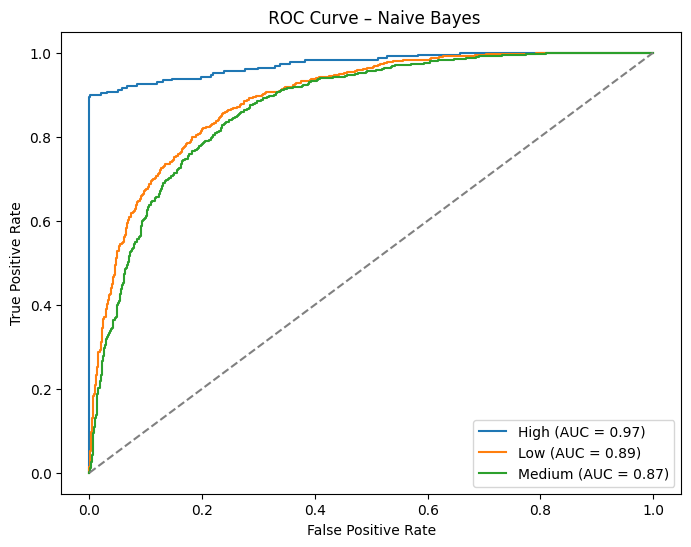

In [81]:

#  ROC Curves
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve – Naive Bayes')
plt.legend()
plt.show()



In [82]:

# Feature Ablation
feature_impact = []
for col in X_train.columns:
    X_train_temp = X_train.drop(col, axis=1)
    X_test_temp = X_test.drop(col, axis=1)
    nb_temp = CategoricalNB()
    nb_temp.fit(X_train_temp, y_train)
    y_test_temp_pred = nb_temp.predict(X_test_temp)
    acc = accuracy_score(y_test, y_test_temp_pred)
    feature_impact.append((col, acc))

feature_impact_df = pd.DataFrame(feature_impact, columns=['Feature Removed', 'Test Accuracy']).sort_values('Test Accuracy')
print("Feature Ablation – Test Accuracy")
display(feature_impact_df)

Feature Ablation – Test Accuracy


,Feature Removed,Test Accuracy
9,Stress Level (1-10),0.595909
3,Sleep Hours,0.788182
5,Caffeine Intake (mg/day),0.789091
16,Recent Major Life Event,0.790909
13,Dizziness,0.791364
17,Diet Quality (1-10),0.792727
6,Alcohol Consumption (drinks/week),0.793636
12,Sweating Level (1-5),0.793636
1,Gender,0.793636
4,Physical Activity (hrs/week),0.794091


Decision Tree Classifier


In [83]:

#  Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    log_loss, confusion_matrix, roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


#  Prepare Dataset
X = df.drop(['Anxiety Level (1-10)', 'Anxiety_Level_Category'], axis=1, errors='ignore')
y_class = df['Anxiety Level (1-10)'].apply(lambda level: "Low" if level <= 3 else ("Medium" if level <= 6 else "High"))

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

#  Encode Categorical Features
cat_cols = X_train.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    le_dict[col] = le

#  Apply SMOTE for balancing
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Balanced Training Set Distribution:")
print(pd.Series(y_train_res).value_counts())

# Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

print(" Best Parameters:", grid.best_params_)
print(" Best CV Accuracy:", grid.best_score_)


#  Train Decision Tree with Best Parameters
dt_clf = DecisionTreeClassifier(**grid.best_params_, random_state=42)
dt_clf.fit(X_train_res, y_train_res)

#  Predictions
y_train_pred = dt_clf.predict(X_train_res)
y_test_pred = dt_clf.predict(X_test)
y_train_proba = dt_clf.predict_proba(X_train_res)
y_test_proba = dt_clf.predict_proba(X_test)




Balanced Training Set Distribution:
Anxiety Level (1-10)
Low       4161
Medium    4161
High      4161
Name: count, dtype: int64
 Best Parameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 15}
 Best CV Accuracy: 0.8009291919534209


In [84]:

#  Evaluation Metrics Function
def classification_metrics(y_true, y_pred, y_proba, classes):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
    loss = log_loss(y_true, y_proba)
    macro_auc = roc_auc_score(label_binarize(y_true, classes=classes), y_proba, average='macro')
    return accuracy, precision, recall, f1, f2, loss, macro_auc

classes = dt_clf.classes_
train_metrics = classification_metrics(y_train_res, y_train_pred, y_train_proba, classes)
test_metrics = classification_metrics(y_test, y_test_pred, y_test_proba, classes)


In [85]:

# Metrics Tables
# Train set metrics
train_metrics_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics
})
print("Decision Tree – Train Set Metrics")
display(train_metrics_table)

# Train vs Test comparison
comparison_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})
print(" Decision Tree – Train vs Test Metrics")
display(comparison_table)



Decision Tree – Train Set Metrics


,Metric,Train Set
0,Accuracy,0.825923
1,Precision,0.832009
2,Recall,0.825923
3,F1 Score,0.828230
4,F2 Score,0.826670
5,Log Loss,0.405268
6,Macro-Average AUC,0.939713


 Decision Tree – Train vs Test Metrics


,Metric,Train Set,Test Set
0,Accuracy,0.825923,0.772727
1,Precision,0.832009,0.774481
2,Recall,0.825923,0.772727
3,F1 Score,0.828230,0.773092
4,F2 Score,0.826670,0.772750
5,Log Loss,0.405268,0.609980
6,Macro-Average AUC,0.939713,0.896768


In [86]:

# Confusion Matrix – Test Set
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=[f'Actual {c}' for c in classes],
                     columns=[f'Pred {c}' for c in classes])
print("Confusion Matrix – Test Set")
display(cm_df)



Confusion Matrix – Test Set


,Pred High,Pred Low,Pred Medium
Actual High,204,0,23
Actual Low,3,786,252
Actual Medium,22,200,710


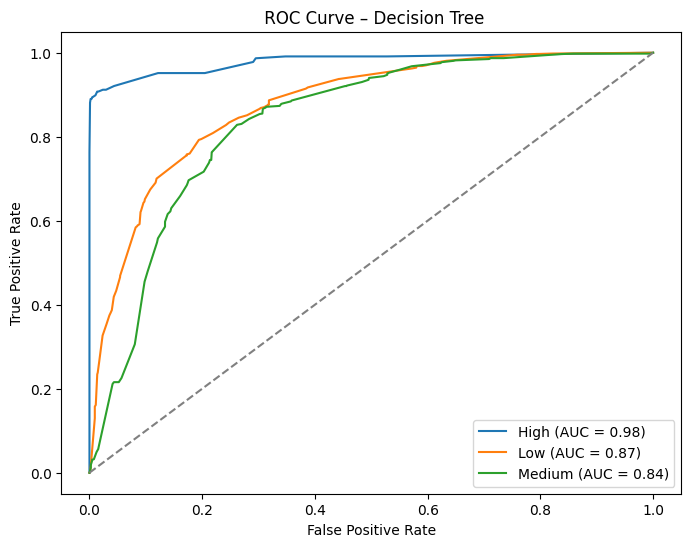

In [87]:

# ROC Curves
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve – Decision Tree')
plt.legend()
plt.show()

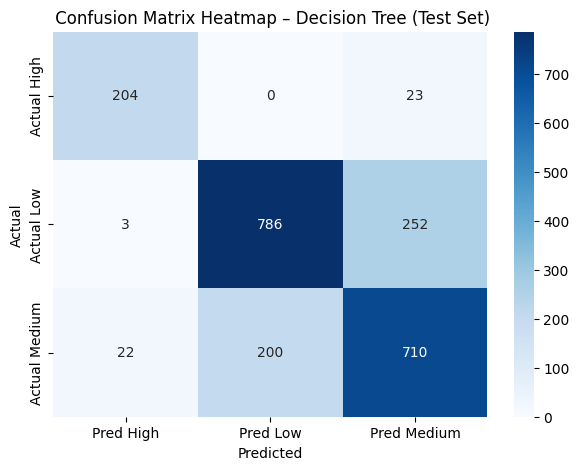

In [88]:

#  Confusion Matrix Heatmap – Test Set
plt.figure(figsize=(7,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(" Confusion Matrix Heatmap – Decision Tree (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Tuned Decision Tree

In [89]:

#  Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    log_loss, confusion_matrix, roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

#  Convert Anxiety Scores to Categories
def categorize_anxiety(level):
    if level <= 3:
        return "Low"
    elif level <= 6:
        return "Medium"
    else:
        return "High"

y_class = df['Anxiety Level (1-10)'].apply(categorize_anxiety)
X = df.drop(['Anxiety Level (1-10)'], axis=1)

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

#  Encode Categorical Features
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    le_dict[col] = le

#  Remove Highly Correlated Features
corr_matrix = X_train[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

print("Dropped highly correlated features:", to_drop)

#  Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Balanced Training Distribution:")
print(pd.Series(y_train_res).value_counts())

# Feature Scaling (Optional)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Cross-Validation & Decision Tree Training
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=15, min_samples_leaf=5, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt, X_train_scaled, y_train_res, cv=cv, scoring='accuracy')
print(" CV Accuracy Scores:", cv_scores)
print(" Mean CV Accuracy:", cv_scores.mean())

# Train on full training set
dt.fit(X_train_scaled, y_train_res)

#  Predictions
y_train_pred = dt.predict(X_train_scaled)
y_test_pred = dt.predict(X_test_scaled)

y_train_proba = dt.predict_proba(X_train_scaled)
y_test_proba = dt.predict_proba(X_test_scaled)



Dropped highly correlated features: []
Balanced Training Distribution:
Anxiety Level (1-10)
Low       4161
Medium    4161
High      4161
Name: count, dtype: int64
 CV Accuracy Scores: [0.96796155 0.97076492 0.97637165 0.96794872 0.97035256]
 Mean CV Accuracy: 0.9706798799585143


In [90]:

# Evaluation Metrics Function

def classification_metrics(y_true, y_pred, y_proba=None, classes=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
    loss = log_loss(y_true, y_proba) if y_proba is not None else None
    macro_auc = None
    if y_proba is not None and classes is not None:
        y_true_bin = label_binarize(y_true, classes=classes)
        macro_auc = roc_auc_score(y_true_bin, y_proba, average='macro')
    return accuracy, precision, recall, f1, f2, loss, macro_auc

classes = dt.classes_
train_metrics = classification_metrics(y_train_res, y_train_pred, y_train_proba, classes)
test_metrics = classification_metrics(y_test, y_test_pred, y_test_proba, classes)


In [91]:

# Metrics Tables
# Train vs Test
comparison_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})
print(" Tuned Decision Tree – Train vs Test Metrics")
display(comparison_table)


 Tuned Decision Tree – Train vs Test Metrics


,Metric,Train Set,Test Set
0,Accuracy,0.974766,0.984091
1,Precision,0.975678,0.984000
2,Recall,0.974766,0.984091
3,F1 Score,0.974643,0.984006
4,F2 Score,0.974579,0.984048
5,Log Loss,0.066808,0.064515
6,Macro-Average AUC,0.997232,0.993496


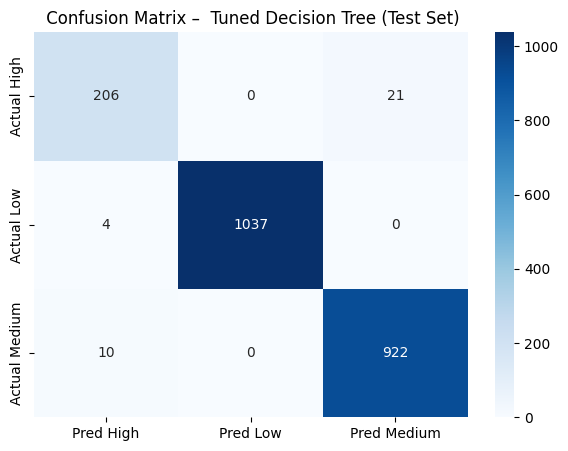

In [92]:

#  Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=[f'Actual {c}' for c in classes],
                     columns=[f'Pred {c}' for c in classes])

plt.figure(figsize=(7,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(" Confusion Matrix –  Tuned Decision Tree (Test Set)")
plt.show()


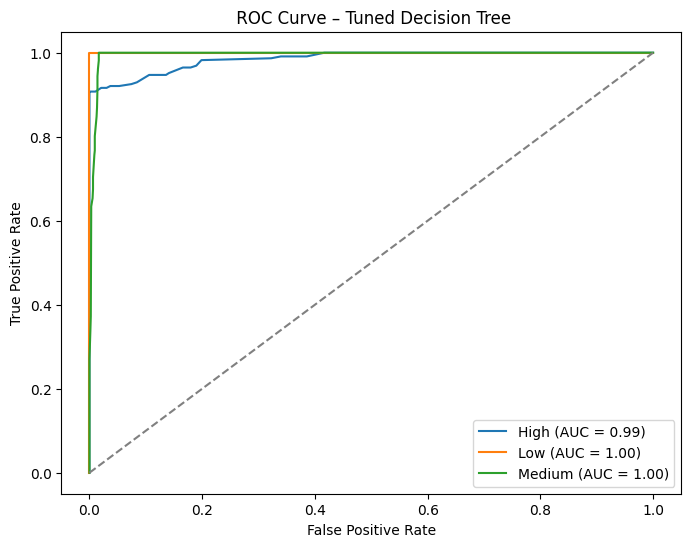

In [93]:

#  ROC Curves
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve – Tuned Decision Tree')
plt.legend()
plt.show()


In [94]:

# Shuffle Labels to Check Data Leakage

y_train_shuffled = y_train_res.sample(frac=1.0, random_state=42).reset_index(drop=True)
dt_shuffled = DecisionTreeClassifier(max_depth=6, min_samples_split=15, min_samples_leaf=5, random_state=42)
dt_shuffled.fit(X_train_scaled, y_train_shuffled)
y_test_pred_shuffled = dt_shuffled.predict(X_test_scaled)
shuffle_acc = accuracy_score(y_test, y_test_pred_shuffled)
print("Accuracy after shuffling labels (should drop):", shuffle_acc)

Accuracy after shuffling labels (should drop): 0.325


In [95]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf_clf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [96]:

# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    log_loss, confusion_matrix, roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


#  Convert Anxiety Scores to Categories
def categorize_anxiety(level):
    if level <= 3:
        return "Low"
    elif level <= 6:
        return "Medium"
    else:
        return "High"

# Target
y_class = df['Anxiety Level (1-10)'].apply(categorize_anxiety)
# Drop original score from features
X = df.drop(['Anxiety Level (1-10)'], axis=1)

#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

#  Encode Categorical Features
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    le_dict[col] = le

#  Remove Highly Correlated Features
corr_matrix = X_train[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)
print("Dropped highly correlated features:", to_drop)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Balanced Training Distribution:")
print(pd.Series(y_train_res).value_counts())

#  Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


# Cross-Validation & Random Forest Training
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_scaled, y_train_res, cv=cv, scoring='accuracy')
print("CV Accuracy Scores:", cv_scores)
print(" Mean CV Accuracy:", cv_scores.mean())

# Train on full training set
rf.fit(X_train_scaled, y_train_res)

# Predictions

y_train_pred = rf.predict(X_train_scaled)
y_test_pred = rf.predict(X_test_scaled)

y_train_proba = rf.predict_proba(X_train_scaled)
y_test_proba = rf.predict_proba(X_test_scaled)

# Evaluation Metrics Function

def classification_metrics(y_true, y_pred, y_proba=None, classes=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
    loss = log_loss(y_true, y_proba) if y_proba is not None else None
    macro_auc = None
    if y_proba is not None and classes is not None:
        y_true_bin = label_binarize(y_true, classes=classes)
        macro_auc = roc_auc_score(y_true_bin, y_proba, average='macro')
    return accuracy, precision, recall, f1, f2, loss, macro_auc

classes = rf.classes_
train_metrics = classification_metrics(y_train_res, y_train_pred, y_train_proba, classes)
test_metrics = classification_metrics(y_test, y_test_pred, y_test_proba, classes)


Dropped highly correlated features: []
Balanced Training Distribution:
Anxiety Level (1-10)
Low       4161
Medium    4161
High      4161
Name: count, dtype: int64
🔹 CV Accuracy Scores: [0.969163   0.97276732 0.97797357 0.96955128 0.96915064]
🔹 Mean CV Accuracy: 0.9717211615477034


In [97]:

#  Metrics Tables

comparison_table = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','F2 Score','Log Loss','Macro-Average AUC'],
    'Train Set': train_metrics,
    'Test Set': test_metrics
})
print("Random Forest – Train vs Test Metrics")
display(comparison_table)



Random Forest – Train vs Test Metrics


,Metric,Train Set,Test Set
0,Accuracy,0.973644,0.990455
1,Precision,0.975112,0.990665
2,Recall,0.973644,0.990455
3,F1 Score,0.973480,0.990276
4,F2 Score,0.973367,0.990319
5,Log Loss,0.108948,0.119943
6,Macro-Average AUC,0.999683,0.993732


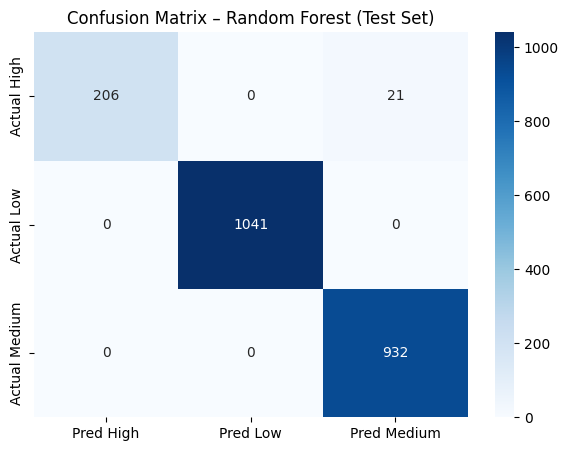

In [98]:

#  Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=[f'Actual {c}' for c in classes],
                     columns=[f'Pred {c}' for c in classes])

plt.figure(figsize=(7,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Random Forest (Test Set)")
plt.show()

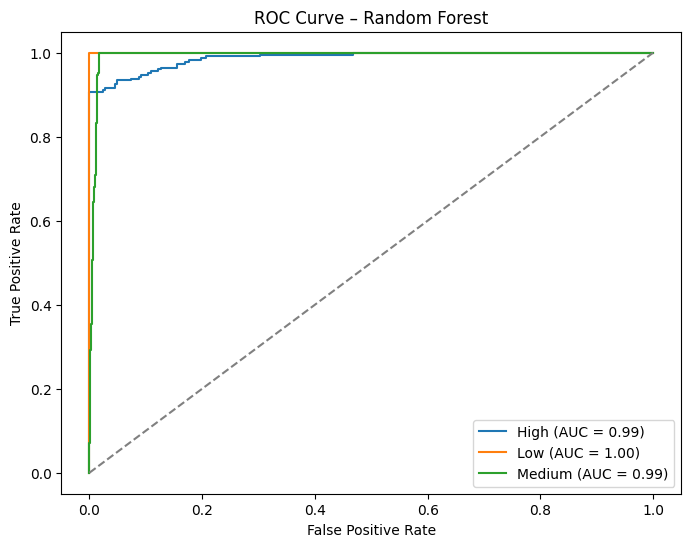

In [99]:

#  ROC Curves
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.show()


In [100]:

# Shuffle Labels to Check Data Leakage

y_train_shuffled = y_train_res.sample(frac=1.0, random_state=42).reset_index(drop=True)
rf_shuffled = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_shuffled.fit(X_train_scaled, y_train_shuffled)
y_test_pred_shuffled = rf_shuffled.predict(X_test_scaled)
shuffle_acc = accuracy_score(y_test, y_test_pred_shuffled)
print("Accuracy after shuffling labels (should drop):", shuffle_acc)

Accuracy after shuffling labels (should drop): 0.44181818181818183


In [101]:
import pandas as pd

# Final Test-Set Metrics of Models
comparison_data = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree (Untuned)",
        "KNN (Untuned)",
        "KNN (Tuned + SMOTE)",
        "Decision Tree (Tuned + SMOTE)",
        "Random Forest (Tuned + SMOTE)"
    ],
    "Accuracy": [
        0.79,
        0.79,
        0.77,
        0.76,
        0.92,
        0.98,
        0.99
    ],
    "Precision": [
        0.79,
        0.79,
        0.77,
        0.76,
        0.92,
        0.98,
        0.99
    ],
    "Recall": [
        0.79,
        0.79,
        0.77,
        0.76,
        0.92,
        0.98,
        0.99
    ],
    "F1 Score": [
        0.79,
        0.79,
        0.77,
        0.76,
        0.92,
        0.98,
        0.99
    ],
    "F2 Score": [
        0.79,
        0.79,
        0.77,
        0.76,
        0.92,
        0.98,
        0.99
    ],
    "Log Loss": [
        0.48,
        0.51,
        0.61,
        0.66,
        0.44,
        0.06,
        0.12
    ],
    "Macro-Average AUC": [
        0.91,
        0.91,
        0.89,
        None,
        None,
        0.99,
        0.99
    ]
}
# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

print("Model Performance Comparison (Test Set)")
display(comparison_df)


Model Performance Comparison (Test Set)


,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,Log Loss,Macro-Average AUC
0,Logistic Regression,0.79,0.79,0.79,0.79,0.79,0.48,0.91
1,Naive Bayes,0.79,0.79,0.79,0.79,0.79,0.51,0.91
2,Decision Tree (Untuned),0.77,0.77,0.77,0.77,0.77,0.61,0.89
3,KNN (Untuned),0.76,0.76,0.76,0.76,0.76,0.66,NaN
4,KNN (Tuned + SMOTE),0.92,0.92,0.92,0.92,0.92,0.44,NaN
5,Decision Tree (Tuned + SMOTE),0.98,0.98,0.98,0.98,0.98,0.06,0.99
6,Random Forest (Tuned + SMOTE),0.99,0.99,0.99,0.99,0.99,0.12,0.99
